# Importing list

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Data Load

In [67]:
df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\Mini Project\Improving Employee Retention by Predicting Employee Attrition Using Machine Learning\tahap01\retention.csv", sep=";")

In [68]:
df.sample(5)

,Username,EnterpriseID,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,...,NomorHP,Email,TingkatPendidikan,PernahBekerja,IkutProgramLOP,AlasanResign,TanggalLahir,TanggalHiring,TanggalPenilaianKaryawan,TanggalResign
219,excludedCoconut6,101499,Belum_menikah,Pria,Outsource,Software Engineer (Android),Mid_level,Sangat_bagus,Jakarta Barat,Diversity_Job_Fair,...,+6287761474xxx,excludedCoconut6557@yahoo.com,Sarjana,1,NaN,NaN,1964-01-04,2012-01-09,2016-01-04,-
239,finickySwift5,105296,Belum_menikah,Wanita,Outsource,Data Analyst,Freshgraduate_program,Biasa,Jakarta Utara,Google_Search,...,+6281213075xxx,finickySwift5808@icloud.com,Magister,1,NaN,internal_conflict,1989-09-08,2011-07-11,2017-02-01,2017-6-25
149,pridefulBuck8,106483,Lainnya,Wanita,Outsource,Software Engineer (Android),Mid_level,Bagus,Jakarta Utara,Website,...,+6289968388xxx,pridefulBuck8335@icloud.com,Sarjana,1,NaN,masih_bekerja,1974-12-05,2014-01-06,2020-1-31,-
16,pacifiedRaisins7,101236,Menikah,Pria,FullTime,Product Manager,Freshgraduate_program,Bagus,Jakarta Pusat,Diversity_Job_Fair,...,+6289563833xxx,pacifiedRaisins7330@outlook.com,Sarjana,1,NaN,masih_bekerja,1976-12-03,2012-01-09,2020-1-31,-
204,boredEggs0,106285,Lainnya,Wanita,FullTime,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Timur,Diversity_Job_Fair,...,+6285733263xxx,boredEggs0225@outlook.com,Sarjana,1,NaN,jam_kerja,1967-06-03,2013-04-01,2020-2-13,2014-8-19


# EDA

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Username                            287 non-null    str    
 1   EnterpriseID                        287 non-null    int64  
 2   StatusPernikahan                    287 non-null    str    
 3   JenisKelamin                        287 non-null    str    
 4   StatusKepegawaian                   287 non-null    str    
 5   Pekerjaan                           287 non-null    str    
 6   JenjangKarir                        287 non-null    str    
 7   PerformancePegawai                  287 non-null    str    
 8   AsalDaerah                          287 non-null    str    
 9   HiringPlatform                      287 non-null    str    
 10  SkorSurveyEngagement                287 non-null    int64  
 11  SkorKepuasanPegawai                 282 non-null    floa

## Missing

In [70]:
print("=== MISSING / NULL VALUES ===")
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
display(null_summary[null_summary['Null Count'] > 0] if df.isnull().sum().sum() > 0 else "No missing values found!")

=== MISSING / NULL VALUES ===


,Null Count,Null Percentage (%)
SkorKepuasanPegawai,5,1.742160
JumlahKeikutsertaanProjek,3,1.045296
JumlahKeterlambatanSebulanTerakhir,1,0.348432
JumlahKetidakhadiran,6,2.090592
IkutProgramLOP,258,89.895470
AlasanResign,66,22.996516


In [71]:
cols=["SkorKepuasanPegawai",
      "JumlahKeikutsertaanProjek",
      "JumlahKeterlambatanSebulanTerakhir",
      "JumlahKetidakhadiran",
      "IkutProgramLOP"]

df[cols].describe().round(2)

,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,IkutProgramLOP
count,282.00,284.00,286.00,281.00,29.00
mean,3.90,1.18,0.41,10.45,0.52
std,0.91,2.29,1.28,6.90,0.51
min,1.00,0.00,0.00,1.00,0.00
25%,3.00,0.00,0.00,5.00,0.00
50%,4.00,0.00,0.00,10.00,1.00
75%,5.00,0.00,0.00,15.00,1.00
max,5.00,8.00,6.00,55.00,1.00


### Handling

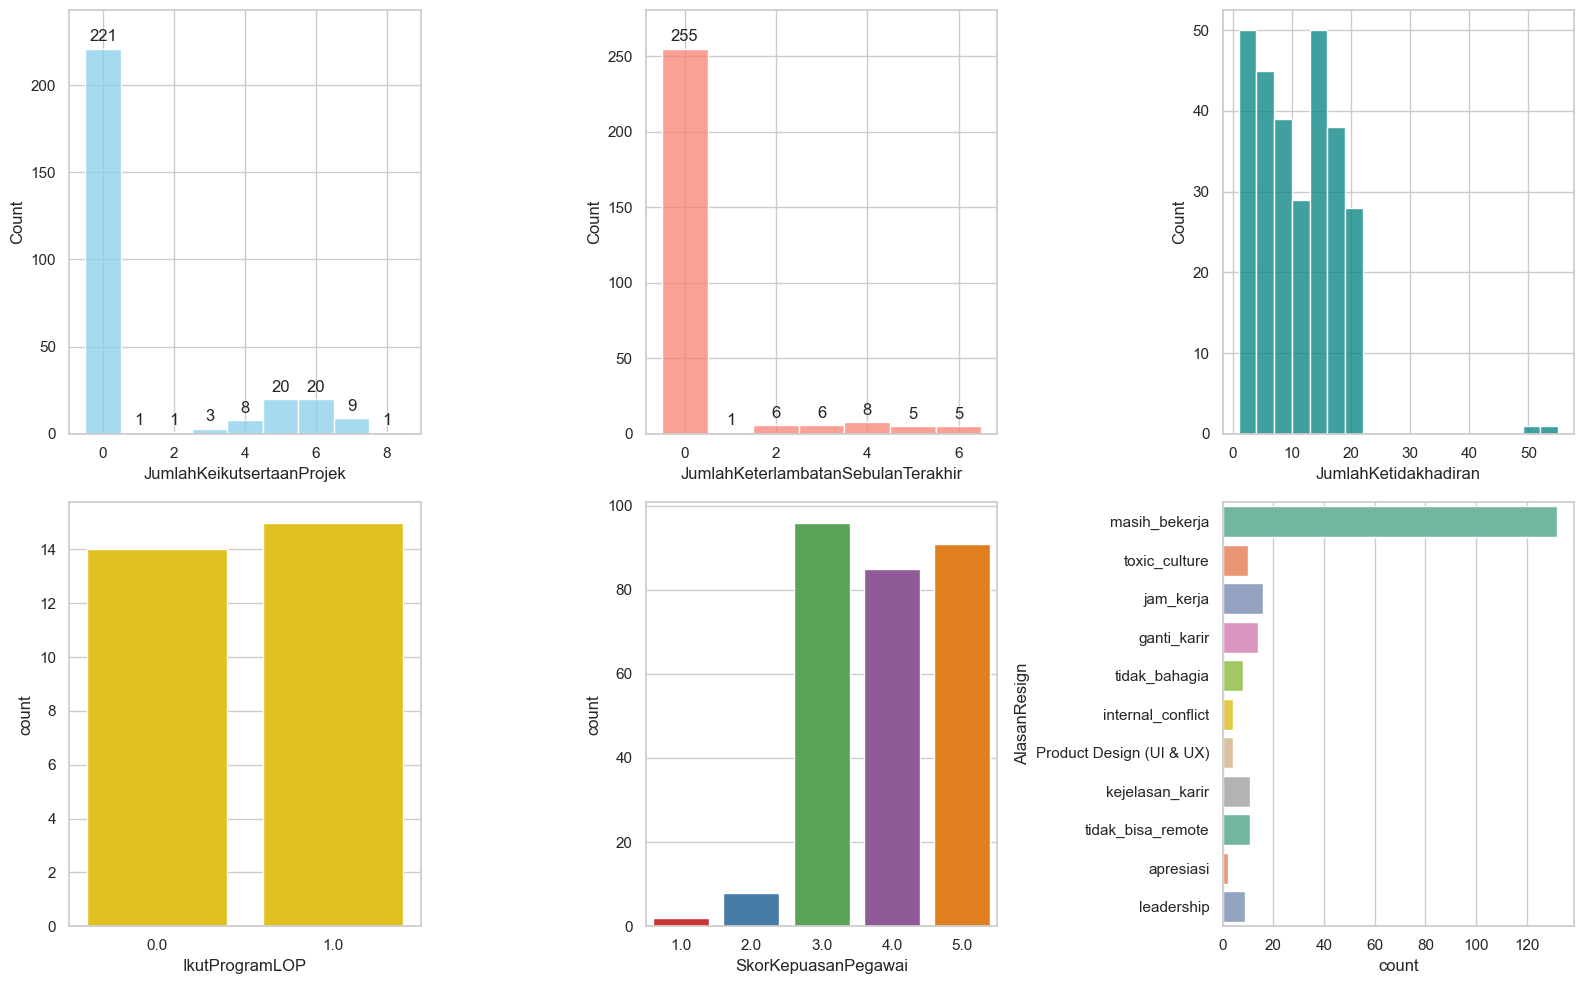

In [72]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

#Numerical Plots (Histograms with KDE)
sns.histplot(df["JumlahKeikutsertaanProjek"], ax=axes[0, 0], color='skyblue', discrete=True)
#Add total counts on top of each bar
axes[0, 0].bar_label(axes[0, 0].containers[0], padding=3)
#Add extra padding at the top so labels don't get cut off
axes[0, 0].margins(y=0.1)

sns.histplot(df["JumlahKeterlambatanSebulanTerakhir"], ax=axes[0, 1], color='salmon', discrete=True)
axes[0, 1].bar_label(axes[0, 1].containers[0], padding=3)
axes[0, 1].margins(y=0.1)

sns.histplot(df["JumlahKetidakhadiran"], ax=axes[0, 2], color='teal')

# Categorical Distributions
sns.countplot(x="IkutProgramLOP", data=df, ax=axes[1, 0], color='gold', legend=False)

sns.countplot(
    x="SkorKepuasanPegawai",
    data=df,
    ax=axes[1, 1],
    hue="SkorKepuasanPegawai",
    palette="Set1",
    legend=False,  # Hides unnecessary legend created by hue
)

sns.countplot(
    y="AlasanResign",
    data=df,
    ax=axes[1, 2],
    hue="AlasanResign",
    palette="Set2",
    legend=False,
)

plt.tight_layout()
plt.show()

In [73]:
df["SkorKepuasanPegawai"]=df["SkorKepuasanPegawai"].fillna(df["SkorKepuasanPegawai"].median())
df["JumlahKeikutsertaanProjek"]=df["JumlahKeikutsertaanProjek"].fillna(df["JumlahKeikutsertaanProjek"].mode())
df["JumlahKeterlambatanSebulanTerakhir"]=df["JumlahKeterlambatanSebulanTerakhir"].fillna(df["JumlahKeterlambatanSebulanTerakhir"].median())
df["JumlahKetidakhadiran"]=df["JumlahKetidakhadiran"].fillna(df["JumlahKetidakhadiran"].median())
df["IkutProgramLOP"]=df["IkutProgramLOP"].fillna(0)
df["AlasanResign"]=df["AlasanResign"].fillna("Lainnya")

## Dupli

In [74]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


## Adding Columns

In [75]:
#TanggalLahir change into date format
df["TanggalLahir"] = pd.to_datetime(df["TanggalLahir"])

#Extract birth year assume the year is 2020/10
df["Age"] = 2020 - df["TanggalLahir"].dt.year

In [76]:
#Convert columns to datetime
#errors='coerce' to turns "-" or any invalid date into NaN
df["TanggalHiring"] = pd.to_datetime(df["TanggalHiring"], errors="coerce")
df["TanggalResign"] = pd.to_datetime(df["TanggalResign"], errors="coerce")

#Assume cutoff date (2020/10/01)
cutoff_date = pd.Timestamp("2020-10-01")

#Fill NaN values with the cutoff date
end_date = df["TanggalResign"].fillna(cutoff_date)

#counting how long the workdays
df["LamaBekerja(Hari)"] = (end_date - df["TanggalHiring"]).dt.days

#Fix any potential negative days (e.g. if hired after Sept 2020)
df["LamaBekerja(Hari)"] = df["LamaBekerja(Hari)"].clip(lower=0)

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_34596\2291396135.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TanggalResign"] = pd.to_datetime(df["TanggalResign"], errors="coerce")


In [77]:
#List of values or patterns that represent active employees
still_working=["masih_bekerja", "-", ""]

# Check if 'AlasanResign' is NOT in still_working_values AND is NOT missing (NaN)
is_resigned = (
    ~df["AlasanResign"].isin(still_working) & df["AlasanResign"].notna()
)

# Convert True/False boolean directly into 1/0 integers
df["Resign"] = is_resigned.astype(int)

In [78]:
# Check total count of Resigned (1) vs Still Working (0)
print(df["Resign"].value_counts())

# Cross-tabulate with original AlasanResign to double check
print(pd.crosstab(df["AlasanResign"].fillna("NaN"), df["Resign"]))

Resign
1    155
0    132
Name: count, dtype: int64
Resign                      0   1
AlasanResign                     
Lainnya                     0  66
Product Design (UI & UX)    0   4
apresiasi                   0   2
ganti_karir                 0  14
internal_conflict           0   4
jam_kerja                   0  16
kejelasan_karir             0  11
leadership                  0   9
masih_bekerja             132   0
tidak_bahagia               0   8
tidak_bisa_remote           0  11
toxic_culture               0  10


## Dropping Columns

In [79]:
col_to_drop=["Username",
             "EnterpriseID",
             "NomorHP",
             "Email",
             "TanggalLahir",
             "TanggalHiring",
             "TanggalPenilaianKaryawan",
             "TanggalResign"
             ]

df01=df.drop(columns=col_to_drop)
df01.sample(5)

,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,SkorSurveyEngagement,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,TingkatPendidikan,PernahBekerja,IkutProgramLOP,AlasanResign,Age,LamaBekerja(Hari),Resign
169,Belum_menikah,Wanita,FullTime,Software Engineer (Back End),Mid_level,Kurang,Jakarta Barat,Indeed,5,4.0,6.0,0.0,3.0,Sarjana,1,0.0,masih_bekerja,33,2516,0
155,Lainnya,Pria,FullTime,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Pusat,Diversity_Job_Fair,4,4.0,0.0,3.0,15.0,Sarjana,1,0.0,masih_bekerja,46,3104,0
48,Belum_menikah,Wanita,FullTime,Product Design (UI & UX),Freshgraduate_program,Biasa,Jakarta Pusat,LinkedIn,3,4.0,0.0,0.0,18.0,Magister,1,0.0,masih_bekerja,36,2740,0
36,Belum_menikah,Wanita,FullTime,Software Engineer (Front End),Mid_level,Bagus,Jakarta Timur,Google_Search,2,5.0,0.0,1.0,19.0,Sarjana,1,0.0,masih_bekerja,56,3335,0
135,Belum_menikah,Pria,Outsource,Data Engineer,Freshgraduate_program,Sangat_bagus,Jakarta Selatan,Diversity_Job_Fair,1,4.0,0.0,2.0,16.0,Sarjana,1,0.0,masih_bekerja,36,2328,0


## Rechecking

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_34596\3897543744.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df01.select_dtypes(
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_34596\3897543744.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_34596\3897543744.py:28: FutureWarning:

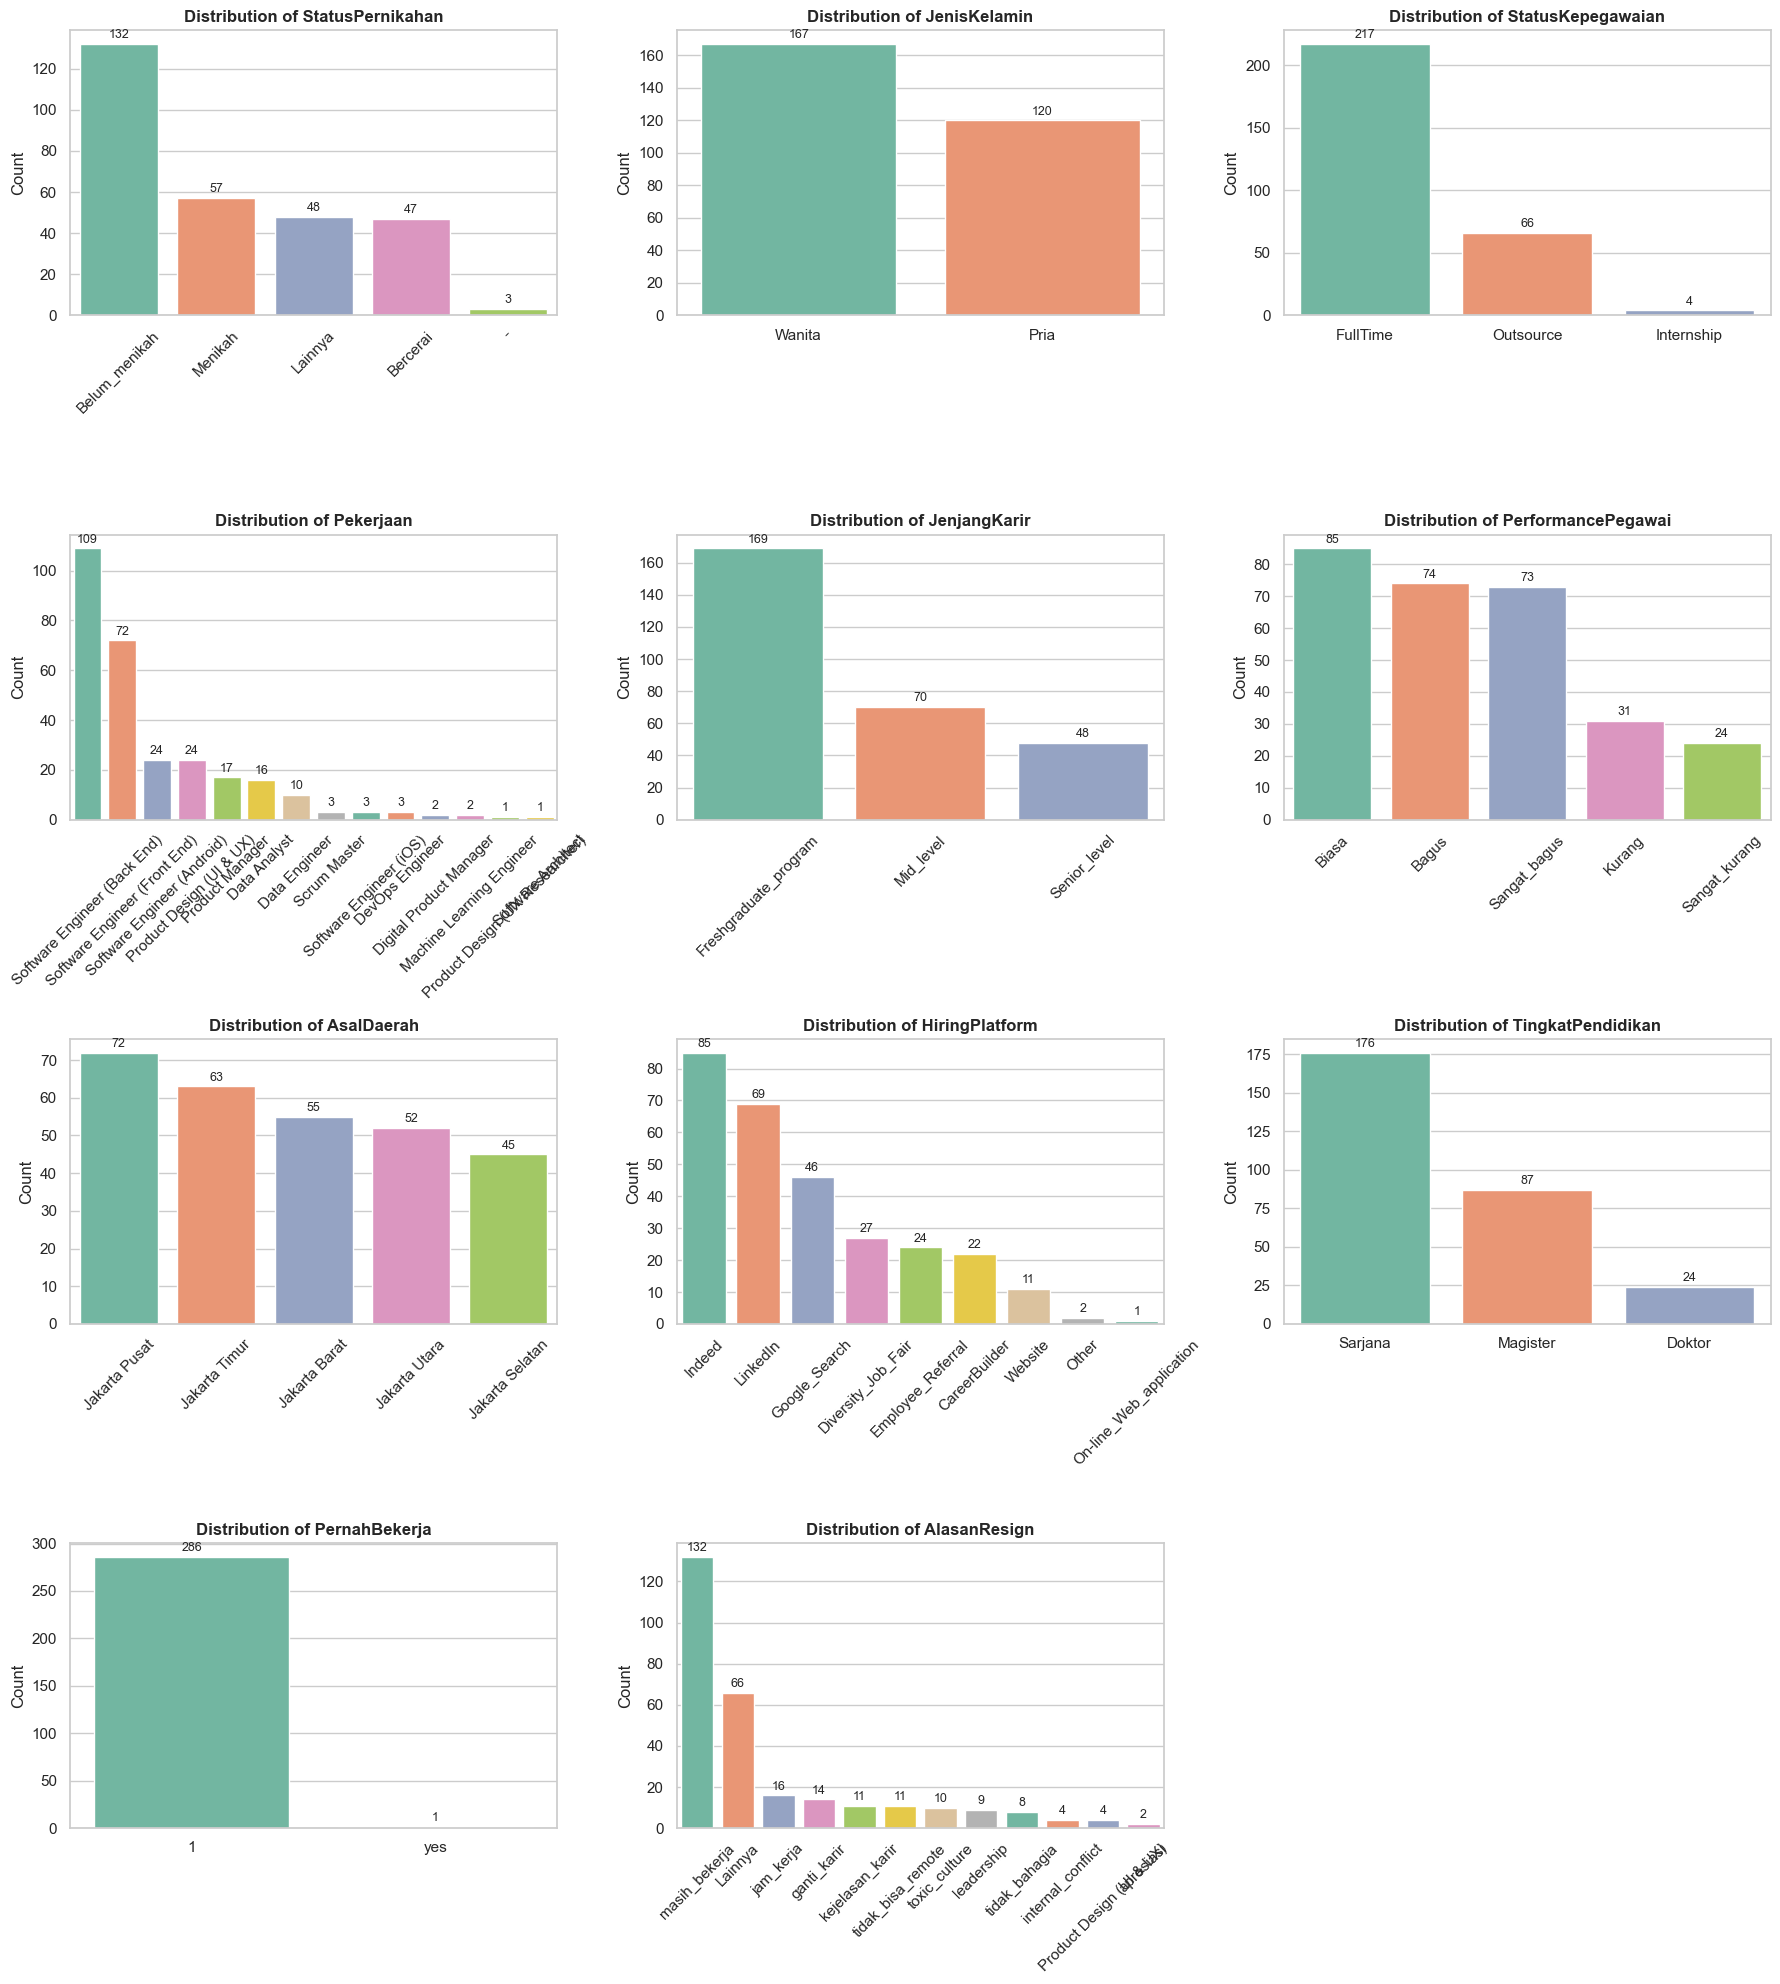

In [80]:
import math

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all categorical (object, category, bool) columns
categorical_cols = df01.select_dtypes(
    include=["object", "category", "bool"]
).columns

# 2. Determine grid layout (e.g., 3 columns per row)
num_cols = len(categorical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy looping

# 4. Loop through columns and plot
for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # Create countplot (ordered by highest frequency)
    order = df01[col].value_counts().index
    sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    # Add count number labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points",
            )

    # Rotate labels if there are many unique values or long string names
    if df01[col].nunique() > 4 or df01[col].astype(str).str.len().max() > 10:
        ax.tick_params(axis="x", rotation=45)

# 5. Hide any extra unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Handling

In [81]:
#replace
df01["StatusPernikahan"]=df01["StatusPernikahan"].replace("-", "Lainnya")

#drop
df01=df01.drop(columns="PernahBekerja")

In [82]:
df01.head(5)

,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,SkorSurveyEngagement,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,TingkatPendidikan,IkutProgramLOP,AlasanResign,Age,LamaBekerja(Hari),Resign
0,Belum_menikah,Pria,Outsource,Software Engineer (Back End),Freshgraduate_program,Sangat_bagus,Jakarta Timur,Employee_Referral,4,4.0,0.0,0.0,9.0,Magister,1.0,masih_bekerja,48,3552,0
1,Belum_menikah,Pria,FullTime,Data Analyst,Freshgraduate_program,Sangat_kurang,Jakarta Utara,Website,4,4.0,4.0,0.0,3.0,Sarjana,1.0,toxic_culture,36,1622,1
2,Menikah,Pria,FullTime,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Timur,Indeed,4,3.0,0.0,0.0,11.0,Magister,1.0,jam_kerja,46,1353,1
3,Belum_menikah,Pria,Outsource,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Pusat,LinkedIn,3,3.0,0.0,4.0,6.0,Sarjana,0.0,masih_bekerja,41,2418,0
4,Belum_menikah,Wanita,FullTime,Product Manager,Freshgraduate_program,Bagus,Jakarta Timur,LinkedIn,3,3.0,0.0,0.0,11.0,Sarjana,0.0,ganti_karir,46,1760,1


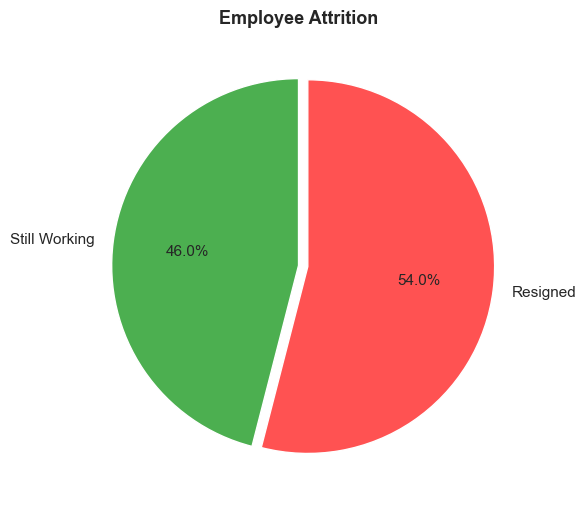

In [83]:
resign_counts = df01["Resign"].value_counts().sort_values(ascending=False)

label_map = {0: "Still Working", 1: "Resigned"}
labels = [label_map[x] for x in resign_counts.index]

color_map = {0: "#4CAF50", 1: "#FF5252"}
colors = [color_map[x] for x in resign_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    resign_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    explode=[0.05 if x == 1 else 0 for x in resign_counts.index],  # Pops out the Resigned slice
    textprops={'fontsize': 11}
)

plt.title("Employee Attrition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Annual Report on Employee Number Changes

--- Aggregated Annual Summary Table ---
 Year  TotalJoined  TotalResigned  NetChange  ActiveEmployees
 2006            1              0          1                1
 2007            2              0          2                3
 2008            2              0          2                5
 2009            7              0          7               12
 2010            8              0          8               20
 2011           76              0         76               96
 2012           41              0         41              137
 2013           43              5         38              175
 2014           56             12         44              219
 2015           31              8         23              242
 2016           14              8          6              248
 2017            5             19        -14              234
 2018            1             26        -25              209
 2019            0              5         -5              204
 2020            0            

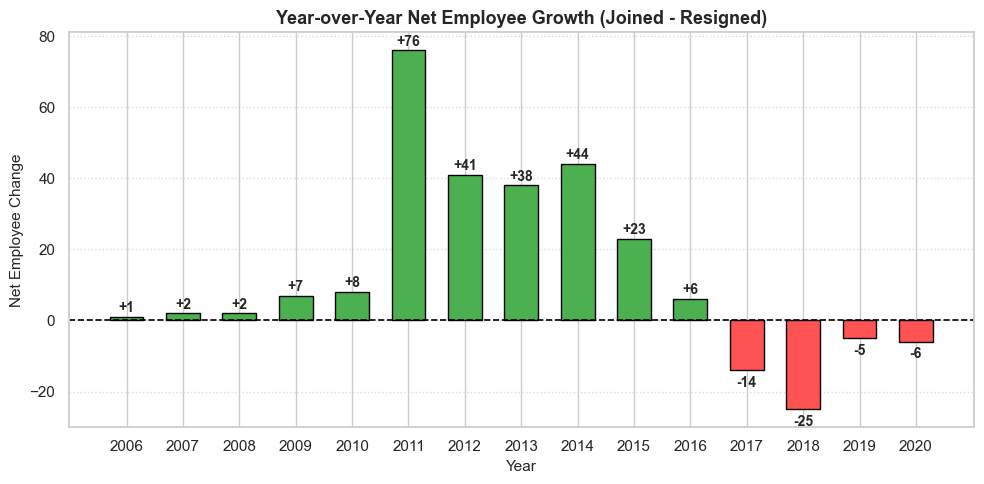

In [84]:
#Plot style
sns.set_theme(style="whitegrid")

#Cutoff date
cutoff_date = pd.Timestamp("2020-10-01")

#Ensuring date in datetime format
df["TanggalHiring"] = pd.to_datetime(df["TanggalHiring"], errors="coerce")
df["TanggalResign"] = pd.to_datetime(df["TanggalResign"], errors="coerce")

#Extract Year features
df["HiringYear"] = df["TanggalHiring"].dt.year
df["ResignYear"] = df["TanggalResign"].dt.year

# ----------------------------------------------------
# 1. Create two aggregate tables (Joined & Resigned counts)
# ----------------------------------------------------
joined_df = (
    df.groupby("HiringYear")
    .size()
    .reset_index(name="TotalJoined")
    .rename(columns={"HiringYear": "Year"})
)

resigned_df = (
    df.groupby("ResignYear")
    .size()
    .reset_index(name="TotalResigned")
    .rename(columns={"ResignYear": "Year"})
)

# ----------------------------------------------------
# 2. Join the two tables using Outer Join
# ----------------------------------------------------
summary_df = pd.merge(joined_df, resigned_df, on="Year", how="outer")

# ----------------------------------------------------
# 3. Handle missing values & sequential years up to 2020
# ----------------------------------------------------
# Convert Year column to integer, filling missing counts with 0
summary_df["TotalJoined"] = summary_df["TotalJoined"].fillna(0).astype(int)
summary_df["TotalResigned"] = summary_df["TotalResigned"].fillna(0).astype(int)

# Create a complete sequential range of years from min year up to 2020
min_year = int(summary_df["Year"].min())
max_year = cutoff_date.year  # 2020

full_years = pd.DataFrame({"Year": range(min_year, max_year + 1)})
summary_df = pd.merge(full_years, summary_df, on="Year", how="left").fillna(0)
summary_df["Year"] = summary_df["Year"].astype(int)
summary_df["TotalJoined"] = summary_df["TotalJoined"].astype(int)
summary_df["TotalResigned"] = summary_df["TotalResigned"].astype(int)

# ----------------------------------------------------
# 4. Calculate Net Change & Cumulative Active Employees
# ----------------------------------------------------
# Yearly Net Change = Total Joined in that year - Total Resigned in that year
summary_df["NetChange"] = summary_df["TotalJoined"] - summary_df["TotalResigned"]

# Cumulative Active Employees at the end of each year
summary_df["ActiveEmployees"] = summary_df["NetChange"].cumsum()

print("--- Aggregated Annual Summary Table ---")
print(summary_df.to_string(index=False))

# ----------------------------------------------------
# 5. Plot the Increases and Decreases (Yearly Net Growth)
# ----------------------------------------------------
plt.figure(figsize=(10, 5))

# Plot Net Change as a Bar Chart with color highlighting
colors = ["#4CAF50" if x >= 0 else "#FF5252" for x in summary_df["NetChange"]]
bars = plt.bar(
    summary_df["Year"],
    summary_df["NetChange"],
    color=colors,
    edgecolor="black",
    width=0.6,
)

# Add data value labels on top of/below each bar
for bar in bars:
    yval = bar.get_height()
    va_align = "bottom" if yval >= 0 else "top"
    y_pos = yval + (0.5 if yval >= 0 else -1.5)
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        y_pos,
        f"{int(yval):+d}",
        ha="center",
        va=va_align,
        fontsize=10,
        fontweight="bold",
    )

plt.axhline(0, color="black", linewidth=1.2, linestyle="--")
plt.xticks(summary_df["Year"])
plt.title(
    "Year-over-Year Net Employee Growth (Joined - Resigned)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Net Employee Change", fontsize=11)
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

# Resign Reason Analysis for Employee Attrition Management Strategy

## Step01

In [85]:
# Non-resigned employees (Resign == 0)
df_active = (
    df01[df01["Resign"] == 0]
    .groupby("Pekerjaan")
    .size()
    .reset_index(name="ActiveCount")
)

# Resigned employees (Resign == 1)
df_resigned = (
    df01[df01["Resign"] == 1]
    .groupby("Pekerjaan")
    .size()
    .reset_index(name="ResignedCount")
)

## Step02

In [86]:
df_merged = pd.merge(df_active, df_resigned, on="Pekerjaan", how="outer").fillna(0)

# Ensure count columns are integer
df_merged["ActiveCount"] = df_merged["ActiveCount"].astype(int)
df_merged["ResignedCount"] = df_merged["ResignedCount"].astype(int)

## Step03

In [87]:
df_merged["TotalEmployees"] = df_merged["ActiveCount"] + df_merged["ResignedCount"]
df_merged["PctRemaining"] = (df_merged["ActiveCount"] / df_merged["TotalEmployees"]) * 100
df_merged["PctResigned"] = (df_merged["ResignedCount"] / df_merged["TotalEmployees"]) * 100

print("--- Job Role Retention Summary ---")
print(df_merged.sort_values(by="PctRemaining", ascending=False).to_string(index=False))

--- Job Role Retention Summary ---
                     Pekerjaan  ActiveCount  ResignedCount  TotalEmployees  PctRemaining  PctResigned
                  Scrum Master            3              0               3    100.000000     0.000000
Product Design (UX Researcher)            1              0               1    100.000000     0.000000
            Software Architect            1              0               1    100.000000     0.000000
       Software Engineer (iOS)            2              1               3     66.666667    33.333333
                 Data Engineer            5              5              10     50.000000    50.000000
       Digital Product Manager            1              1               2     50.000000    50.000000
   Software Engineer (Android)           12             12              24     50.000000    50.000000
      Product Design (UI & UX)           12             12              24     50.000000    50.000000
  Software Engineer (Back End)           52    

## Step04

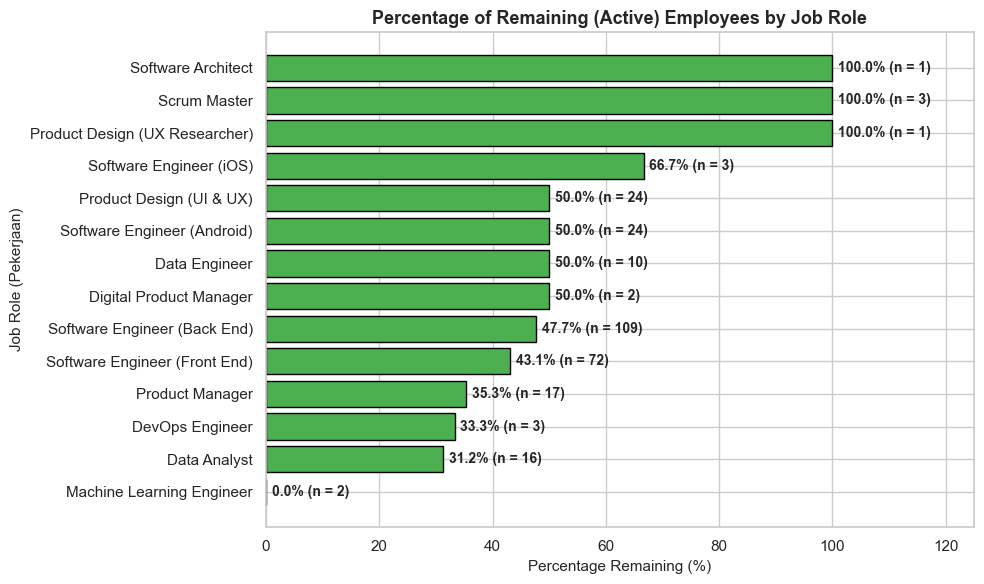

In [88]:
#visualization style
sns.set_theme(style="whitegrid")

# Sort
df_plot = df_merged.sort_values(by="PctRemaining", ascending=True)
sns.set_theme(style="whitegrid")

# Sort by percentage remaining
df_plot = df_merged.sort_values(by="PctRemaining", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    df_plot["Pekerjaan"],
    df_plot["PctRemaining"],
    color="#4CAF50",
    edgecolor="black",
)

# Zip together the bars, total employees, and active employees for annotation
for bar, total, active in zip(
    bars, df_plot["TotalEmployees"], df_plot["ActiveCount"]
):
    width = bar.get_width()

    # Format string to display percentage and total count n
    label = f"{width:.1f}% (n = {total})"

    plt.text(
        width + 1,  # Offset to place text just outside the bar
        bar.get_y() + bar.get_height() / 2.0,
        label,
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )

plt.title(
    "Percentage of Remaining (Active) Employees by Job Role",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Percentage Remaining (%)", fontsize=11)
plt.ylabel("Job Role (Pekerjaan)", fontsize=11)
plt.xlim(0, 125)  # Expanded x-limit to prevent text cutoff
plt.tight_layout()
plt.show()

## Step05

In [89]:
#Division with Highest Resignation Rate & Aggregate by Career Level, Performance, and Resign Reason

# Define target job role directly
target_division = "Software Engineer (Back End)"
print(f"\n[INFO] Analyzing Resignation Breakdown for: {target_division}")

# Filter resigned employees for Software Engineer (Back End)
df_target = df01[(df01["Pekerjaan"] == target_division) & (df01["Resign"] == 1)]

# Aggregation table by Career Level, Performance, and Resign Reason
agg_target = (
    df_target.groupby(["JenjangKarir", "PerformancePegawai", "AlasanResign"])
    .size()
    .reset_index(name="ResignedCount")
    .sort_values(by="ResignedCount", ascending=False)
)

print(f"\n--- Resignation Breakdown for {target_division} ---")
print(agg_target.to_string(index=False))


[INFO] Analyzing Resignation Breakdown for: Software Engineer (Back End)

--- Resignation Breakdown for Software Engineer (Back End) ---
         JenjangKarir PerformancePegawai             AlasanResign  ResignedCount
Freshgraduate_program              Biasa                  Lainnya              5
         Senior_level              Biasa                  Lainnya              5
Freshgraduate_program              Bagus                  Lainnya              4
Freshgraduate_program       Sangat_bagus                  Lainnya              4
         Senior_level              Bagus                  Lainnya              2
            Mid_level       Sangat_bagus                jam_kerja              2
Freshgraduate_program             Kurang                  Lainnya              2
Freshgraduate_program       Sangat_bagus        tidak_bisa_remote              2
Freshgraduate_program      Sangat_kurang                  Lainnya              2
            Mid_level              Biasa            

## Step06

<Figure size 1200x600 with 0 Axes>

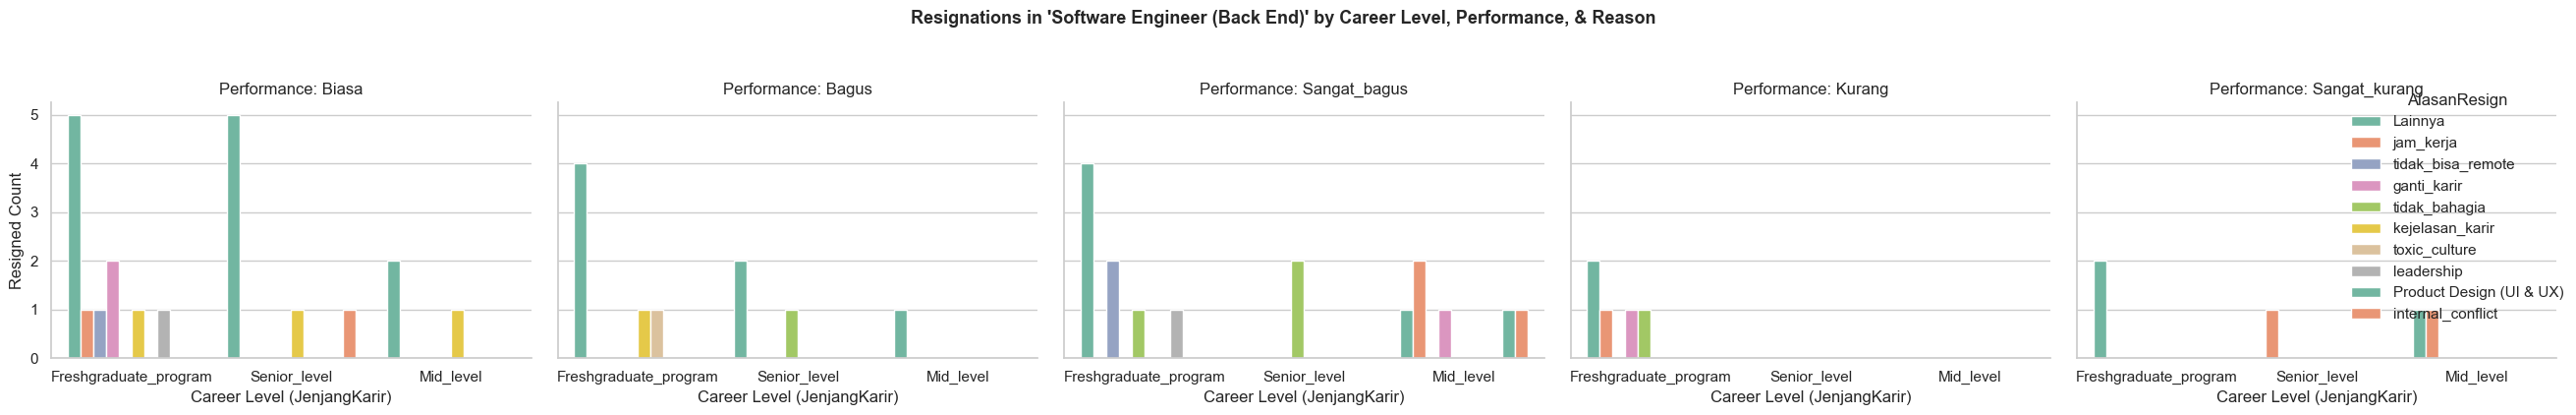

In [90]:
plt.figure(figsize=(12, 6))
chart = sns.catplot(
    data=agg_target,
    x="JenjangKarir",
    y="ResignedCount",
    hue="AlasanResign",
    col="PerformancePegawai",
    kind="bar",
    palette="Set2",
    height=4,
    aspect=1.2,
)

chart.fig.suptitle(
    f"Resignations in '{target_division}' by Career Level, Performance, & Reason",
    y=1.05,
    fontsize=13,
    fontweight="bold",
)
chart.set_axis_labels("Career Level (JenjangKarir)", "Resigned Count")
chart.set_titles("Performance: {col_name}")

plt.tight_layout()
plt.show()

# ML

## Rechecking

In [91]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   StatusPernikahan                    287 non-null    str    
 1   JenisKelamin                        287 non-null    str    
 2   StatusKepegawaian                   287 non-null    str    
 3   Pekerjaan                           287 non-null    str    
 4   JenjangKarir                        287 non-null    str    
 5   PerformancePegawai                  287 non-null    str    
 6   AsalDaerah                          287 non-null    str    
 7   HiringPlatform                      287 non-null    str    
 8   SkorSurveyEngagement                287 non-null    int64  
 9   SkorKepuasanPegawai                 287 non-null    float64
 10  JumlahKeikutsertaanProjek           284 non-null    float64
 11  JumlahKeterlambatanSebulanTerakhir  287 non-null    floa

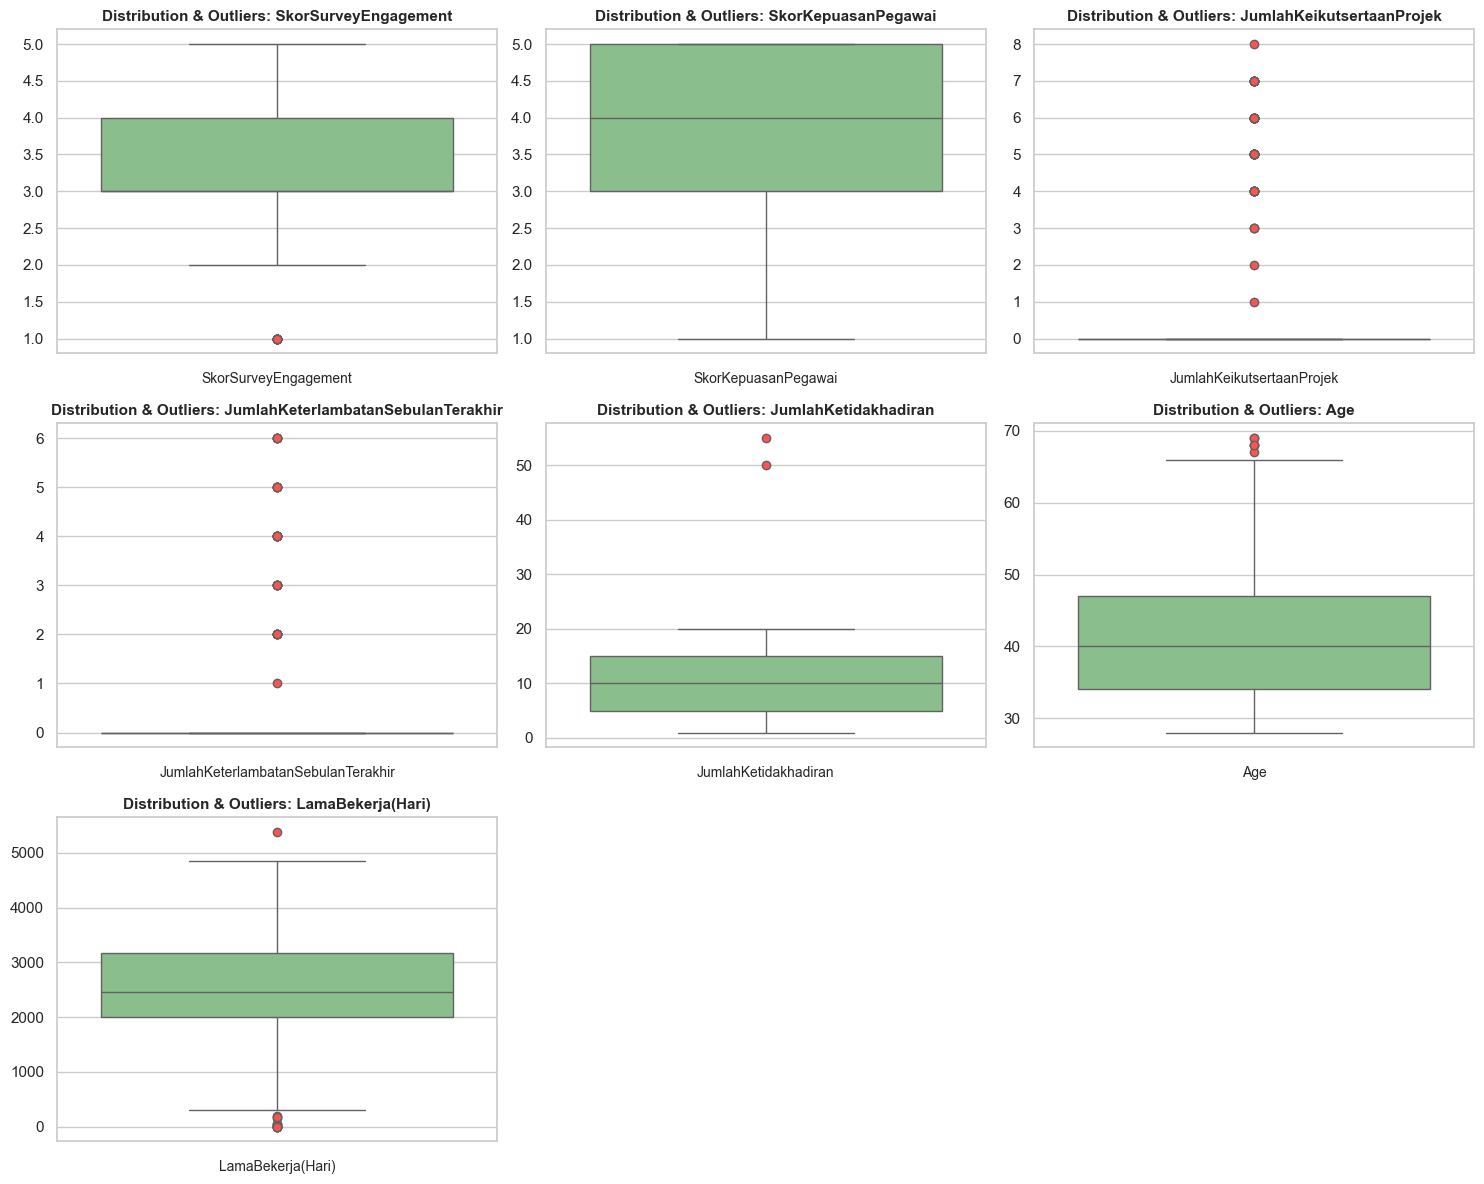

In [92]:
# Select numerical features suitable for box plots
num_cols = [
    "SkorSurveyEngagement",
    "SkorKepuasanPegawai",
    "JumlahKeikutsertaanProjek",
    "JumlahKeterlambatanSebulanTerakhir",
    "JumlahKetidakhadiran",
    "Age",
    "LamaBekerja(Hari)",
]

# Filter to only keep columns that actually exist in df01
available_num_cols = [col for col in num_cols if col in df01.columns]

# Calculate grid dimensions (3 columns per row)
n_cols = 3
n_rows = math.ceil(len(available_num_cols) / n_cols)

# Set figure size based on the number of rows
plt.figure(figsize=(15, 4 * n_rows))

# Generate a box plot for each numerical column
for i, col in enumerate(available_num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        y=df01[col],
        color="#81C784",  # Muted green color
        flierprops={
            "marker": "o",
            "markerfacecolor": "#FF5252",
            "markersize": 6,
        },  # Highlights outliers in red
    )

    plt.title(f"Distribution & Outliers: {col}", fontsize=11, fontweight="bold")
    plt.ylabel("")
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

In [93]:
#numerical
num_cols = [
    "SkorSurveyEngagement",
    "SkorKepuasanPegawai",
    "JumlahKeikutsertaanProjek",
    "JumlahKeterlambatanSebulanTerakhir",
    "JumlahKetidakhadiran",
    "Age",
    "LamaBekerja(Hari)",
]

#Ensure specified numerical columns exist in df01
available_num_cols = [col for col in num_cols if col in df01.columns]

# --- Method 1: Interquartile Range (IQR) Method ---
outlier_summary = []

for col in available_num_cols:
    Q1 = df01[col].quantile(0.25)
    Q3 = df01[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df01[(df01[col] < lower_bound) | (df01[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df01)) * 100

    outlier_summary.append(
        {
            "Feature": col,
            "Outlier Count": outlier_count,
            "Percentage (%)": round(outlier_pct, 2),
            "Lower Bound": round(lower_bound, 2),
            "Upper Bound": round(upper_bound, 2),
            "Min Value": df01[col].min(),
            "Max Value": df01[col].max(),
        }
    )

outlier_df = pd.DataFrame(outlier_summary)
print("=== OUTLIER SUMMARY (IQR METHOD) ===")
print(outlier_df.to_string(index=False))

=== OUTLIER SUMMARY (IQR METHOD) ===
                           Feature  Outlier Count  Percentage (%)  Lower Bound  Upper Bound  Min Value  Max Value
              SkorSurveyEngagement             14            4.88          1.5          5.5        1.0        5.0
               SkorKepuasanPegawai              0            0.00          0.0          8.0        1.0        5.0
         JumlahKeikutsertaanProjek             63           21.95          0.0          0.0        0.0        8.0
JumlahKeterlambatanSebulanTerakhir             31           10.80          0.0          0.0        0.0        6.0
              JumlahKetidakhadiran              2            0.70        -10.0         30.0        1.0       55.0
                               Age              6            2.09         14.5         66.5       28.0       69.0
                 LamaBekerja(Hari)             14            4.88        249.5       4917.5        0.0     5379.0


In [94]:
df01.drop(columns=["AlasanResign"], inplace=True)
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   StatusPernikahan                    287 non-null    str    
 1   JenisKelamin                        287 non-null    str    
 2   StatusKepegawaian                   287 non-null    str    
 3   Pekerjaan                           287 non-null    str    
 4   JenjangKarir                        287 non-null    str    
 5   PerformancePegawai                  287 non-null    str    
 6   AsalDaerah                          287 non-null    str    
 7   HiringPlatform                      287 non-null    str    
 8   SkorSurveyEngagement                287 non-null    int64  
 9   SkorKepuasanPegawai                 287 non-null    float64
 10  JumlahKeikutsertaanProjek           284 non-null    float64
 11  JumlahKeterlambatanSebulanTerakhir  287 non-null    floa

## Remaping

### Pekerjaan

In [95]:
# Define the dictionary mapping each specific role to its high-level domain
job_role_mapping = {
    # Data & AI
    'Data Analyst': 'Data & AI',
    'Data Engineer': 'Data & AI',
    'Machine Learning Engineer': 'Data & AI',
    
    # Product & Design
    'Product Design (UI & UX)': 'Product & Design',
    'Product Design (UX Researcher)': 'Product & Design',
    'Product Manager': 'Product & Design',
    'Digital Product Manager': 'Product & Design',
    
    # Software Engineering
    'Software Engineer (Android)': 'Software Engineering',
    'Software Engineer (Back End)': 'Software Engineering',
    'Software Engineer (Front End)': 'Software Engineering',
    'Software Engineer (iOS)': 'Software Engineering',
    'DevOps Engineer': 'Software Engineering',
    
    # Other
    'Scrum Master': 'Other',
    'Software Architect': 'Other'
}

# Apply mapping to your dataframe column
df01['Pekerjaan'] = df01['Pekerjaan'].map(job_role_mapping)

### HiringPlatform

In [96]:
platform_mapping = {
    # Job_Board
    'Indeed': 'Job_Board',
    'LinkedIn': 'Job_Board',
    'CareerBuilder': 'Job_Board',
    
    # Direct
    'On-line_Web_application': 'Direct',
    'Google_Search': 'Direct',
    'Website': 'Direct',
    
    # Event
    'Diversity_Job_Fair': 'Event',
    'Employee_Referral': 'Event',
    
    #Other
    'Other': 'Other'    
}

df01['HiringPlatform'] = df01['HiringPlatform'].map(platform_mapping)

In [97]:
df01[['Pekerjaan', 'HiringPlatform']].sample(10)

,Pekerjaan,HiringPlatform
93,Software Engineering,Job_Board
141,Software Engineering,Job_Board
56,Product & Design,Job_Board
29,Software Engineering,Job_Board
280,Software Engineering,Event
272,Software Engineering,Job_Board
92,Software Engineering,Job_Board
211,Software Engineering,Job_Board
198,Software Engineering,Job_Board
21,Other,Job_Board


### Gender

In [98]:
df01['JenisKelamin'] = df01['JenisKelamin'].map({'Pria': 1, 'Wanita': 0})

## Dropping

In [99]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   StatusPernikahan                    287 non-null    str    
 1   JenisKelamin                        287 non-null    int64  
 2   StatusKepegawaian                   287 non-null    str    
 3   Pekerjaan                           287 non-null    str    
 4   JenjangKarir                        287 non-null    str    
 5   PerformancePegawai                  287 non-null    str    
 6   AsalDaerah                          287 non-null    str    
 7   HiringPlatform                      287 non-null    str    
 8   SkorSurveyEngagement                287 non-null    int64  
 9   SkorKepuasanPegawai                 287 non-null    float64
 10  JumlahKeikutsertaanProjek           284 non-null    float64
 11  JumlahKeterlambatanSebulanTerakhir  287 non-null    floa

In [100]:
df02 = df01.drop(columns=["LamaBekerja(Hari)"])
df02.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   StatusPernikahan                    287 non-null    str    
 1   JenisKelamin                        287 non-null    int64  
 2   StatusKepegawaian                   287 non-null    str    
 3   Pekerjaan                           287 non-null    str    
 4   JenjangKarir                        287 non-null    str    
 5   PerformancePegawai                  287 non-null    str    
 6   AsalDaerah                          287 non-null    str    
 7   HiringPlatform                      287 non-null    str    
 8   SkorSurveyEngagement                287 non-null    int64  
 9   SkorKepuasanPegawai                 287 non-null    float64
 10  JumlahKeikutsertaanProjek           284 non-null    float64
 11  JumlahKeterlambatanSebulanTerakhir  287 non-null    floa

In [101]:
df02.isnull().sum()

StatusPernikahan                      0
JenisKelamin                          0
StatusKepegawaian                     0
Pekerjaan                             0
JenjangKarir                          0
PerformancePegawai                    0
AsalDaerah                            0
HiringPlatform                        0
SkorSurveyEngagement                  0
SkorKepuasanPegawai                   0
JumlahKeikutsertaanProjek             3
JumlahKeterlambatanSebulanTerakhir    0
JumlahKetidakhadiran                  0
TingkatPendidikan                     0
IkutProgramLOP                        0
Age                                   0
Resign                                0
dtype: int64

In [102]:
df02["JumlahKeikutsertaanProjek"] = df02["JumlahKeikutsertaanProjek"].fillna(0)
df02.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   StatusPernikahan                    287 non-null    str    
 1   JenisKelamin                        287 non-null    int64  
 2   StatusKepegawaian                   287 non-null    str    
 3   Pekerjaan                           287 non-null    str    
 4   JenjangKarir                        287 non-null    str    
 5   PerformancePegawai                  287 non-null    str    
 6   AsalDaerah                          287 non-null    str    
 7   HiringPlatform                      287 non-null    str    
 8   SkorSurveyEngagement                287 non-null    int64  
 9   SkorKepuasanPegawai                 287 non-null    float64
 10  JumlahKeikutsertaanProjek           287 non-null    float64
 11  JumlahKeterlambatanSebulanTerakhir  287 non-null    floa

## seperating target

In [103]:
X = df02.drop("Resign", axis=1)
y = df02["Resign"]

## Encoding

In [104]:
categorical_cols = X.select_dtypes(include="object").columns
categorical_cols

numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_34596\2443631883.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [105]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [106]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   JenisKelamin                        287 non-null    int64  
 1   SkorSurveyEngagement                287 non-null    int64  
 2   SkorKepuasanPegawai                 287 non-null    float64
 3   JumlahKeikutsertaanProjek           287 non-null    float64
 4   JumlahKeterlambatanSebulanTerakhir  287 non-null    float64
 5   JumlahKetidakhadiran                287 non-null    float64
 6   IkutProgramLOP                      287 non-null    float64
 7   Age                                 287 non-null    int32  
 8   StatusPernikahan_Bercerai           287 non-null    int64  
 9   StatusPernikahan_Lainnya            287 non-null    int64  
 10  StatusPernikahan_Menikah            287 non-null    int64  
 11  StatusKepegawaian_Internship        287 non-null    int6

## Train-Test

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Standardization

In [108]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

## Logistic Regresion

### Scaling

In [109]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model

In [110]:
Logis = LogisticRegression(max_iter=1000)
Logis.fit(X_train_scaled, y_train)
pred_lr = Logis.predict(X_test_scaled)
prob_lr = Logis.predict_proba(X_test_scaled)[:,1]

### Eval

In [111]:
print(f"Accuracy : {accuracy_score(y_test, pred_lr):.2f}")
print(f"Precision: {precision_score(y_test, pred_lr):.2f}")
print(f"Recall   : {recall_score(y_test, pred_lr):.2f}")
print(f"F1 Score : {f1_score(y_test, pred_lr):.2f}")
print(f"ROC AUC  : {roc_auc_score(y_test, prob_lr):.2f}")
print(classification_report(y_test, pred_lr, digits=2))

Accuracy : 0.52
Precision: 0.54
Recall   : 0.68
F1 Score : 0.60
ROC AUC  : 0.54
              precision    recall  f1-score   support

           0       0.47      0.33      0.39        27
           1       0.54      0.68      0.60        31

    accuracy                           0.52        58
   macro avg       0.51      0.51      0.50        58
weighted avg       0.51      0.52      0.50        58



## Random Forest

### Model

In [112]:
RandomForest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

RandomForest.fit(X_train, y_train)
pred_rf = RandomForest.predict(X_test)
prob_rf = RandomForest.predict_proba(X_test)[:,1]

### Eval

In [113]:
print(f"Accuracy : {accuracy_score(y_test, pred_rf):.2f}")
print(f"Precision: {precision_score(y_test, pred_rf):.2f}")
print(f"Recall   : {recall_score(y_test, pred_rf):.2f}")
print(f"F1 Score : {f1_score(y_test, pred_rf):.2f}")
print(f"ROC AUC  : {roc_auc_score(y_test, prob_rf):.2f}")

print(classification_report(y_test, pred_rf, digits=2))

Accuracy : 0.66
Precision: 0.66
Recall   : 0.74
F1 Score : 0.70
ROC AUC  : 0.69
              precision    recall  f1-score   support

           0       0.65      0.56      0.60        27
           1       0.66      0.74      0.70        31

    accuracy                           0.66        58
   macro avg       0.65      0.65      0.65        58
weighted avg       0.65      0.66      0.65        58



### Feature Importance

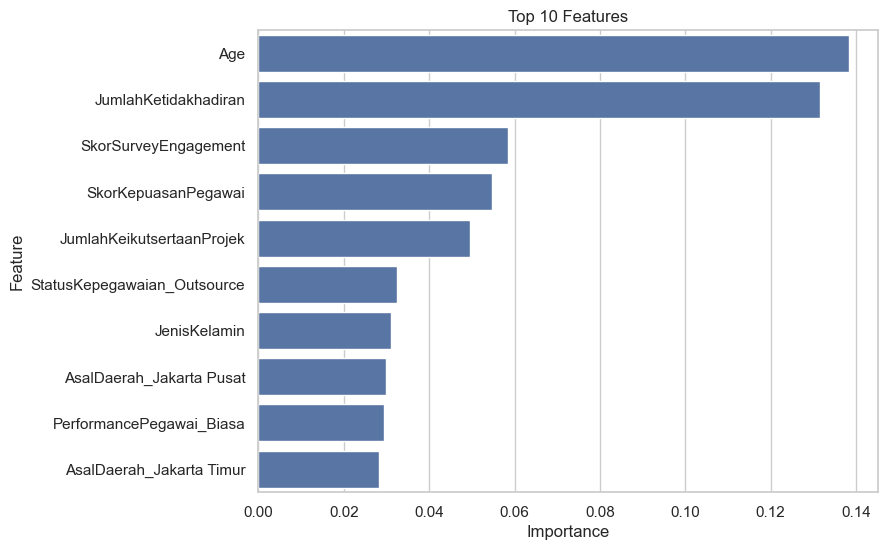

In [114]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": RandomForest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Features")
plt.show()

## XGBoost

### Model

In [115]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
prob_xgb = xgb.predict_proba(X_test)[:,1]

### Eval

In [116]:
print(f"Accuracy : {accuracy_score(y_test, pred_xgb):.2f}")
print(f"Precision: {precision_score(y_test, pred_xgb):.2f}")
print(f"Recall   : {recall_score(y_test, pred_xgb):.2f}")
print(f"F1 Score : {f1_score(y_test, pred_xgb):.2f}")
print(f"ROC AUC  : {roc_auc_score(y_test, prob_xgb):.2f}")

print(classification_report(y_test, pred_xgb, digits=2))

Accuracy : 0.60
Precision: 0.62
Recall   : 0.65
F1 Score : 0.63
ROC AUC  : 0.68
              precision    recall  f1-score   support

           0       0.58      0.56      0.57        27
           1       0.62      0.65      0.63        31

    accuracy                           0.60        58
   macro avg       0.60      0.60      0.60        58
weighted avg       0.60      0.60      0.60        58



# Models Compare

In [117]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_xgb)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, prob_lr),
        roc_auc_score(y_test, prob_rf),
        roc_auc_score(y_test, prob_xgb)
    ]
})

#
results = results.sort_values(by="F1 Score", ascending=False).round(2)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.66,0.66,0.74,0.70,0.69
2,XGBoost,0.60,0.62,0.65,0.63,0.68
0,Logistic Regression,0.52,0.54,0.68,0.60,0.54


## Hyperparameter Tuning

### Random Forest

In [118]:
from sklearn.model_selection import RandomizedSearchCV

In [119]:
#Define parameter grid
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [120]:
#Random search
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... vers

In [121]:
#best parameter
print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest CV Score:")
print(rf_random.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}

Best CV Score:
0.6546531676846157


In [122]:
best_rf = rf_random.best_estimator_

pred_rf = best_rf.predict(X_test)

prob_rf = best_rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred_rf))

print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, prob_rf))

              precision    recall  f1-score   support

           0       0.67      0.37      0.48        27
           1       0.60      0.84      0.70        31

    accuracy                           0.62        58
   macro avg       0.64      0.60      0.59        58
weighted avg       0.63      0.62      0.60        58

Accuracy : 0.6206896551724138
Precision: 0.6046511627906976
Recall   : 0.8387096774193549
F1 Score : 0.7027027027027027
ROC AUC  : 0.6547192353643966


### XGBoost

In [ ]:
#ParameterGrid
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

In [133]:
#RandomSearch
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=xgb_params,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [134]:
print(xgb_random.best_params_)
print(xgb_random.best_score_)

{'subsample': 0.6, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.8}
0.6268775173681507


In [135]:
best_xgb = xgb_random.best_estimator_

pred_xgb = best_xgb.predict(X_test)

prob_xgb = best_xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred_xgb))

print("Accuracy :", accuracy_score(y_test, pred_xgb))
print("Precision:", precision_score(y_test, pred_xgb))
print("Recall   :", recall_score(y_test, pred_xgb))
print("F1 Score :", f1_score(y_test, pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, prob_xgb))

              precision    recall  f1-score   support

           0       0.73      0.41      0.52        27
           1       0.63      0.87      0.73        31

    accuracy                           0.66        58
   macro avg       0.68      0.64      0.63        58
weighted avg       0.68      0.66      0.63        58

Accuracy : 0.6551724137931034
Precision: 0.627906976744186
Recall   : 0.8709677419354839
F1 Score : 0.7297297297297297
ROC AUC  : 0.6403823178016727


### Logistic Regression

In [136]:
from sklearn.model_selection import GridSearchCV

In [137]:
#ParameterGrid
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

In [139]:
#Search
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

c:\Users\arya wardhana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [140]:
best_lr = lr_grid.best_estimator_

pred_lr = best_lr.predict(X_test_scaled)

prob_lr = best_lr.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, pred_lr))

print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall   :", recall_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, prob_lr))

              precision    recall  f1-score   support

           0       0.47      0.33      0.39        27
           1       0.54      0.68      0.60        31

    accuracy                           0.52        58
   macro avg       0.51      0.51      0.50        58
weighted avg       0.51      0.52      0.50        58

Accuracy : 0.5172413793103449
Precision: 0.5384615384615384
Recall   : 0.6774193548387096
F1 Score : 0.6
ROC AUC  : 0.5376344086021506


### Compare

In [142]:
results_tuned = pd.DataFrame({
    "Model": [
        "Logistic Regression (Tuned)",
        "Random Forest (Tuned)",
        "XGBoost (Tuned)"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_xgb)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, prob_lr),
        roc_auc_score(y_test, prob_rf),
        roc_auc_score(y_test, prob_xgb)
    ]
})

results_tuned = results_tuned.sort_values(
    by="F1 Score",
    ascending=False
).round(2)

results_tuned

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,XGBoost (Tuned),0.66,0.63,0.87,0.73,0.64
1,Random Forest (Tuned),0.62,0.60,0.84,0.70,0.69
0,Logistic Regression (Tuned),0.52,0.54,0.68,0.60,0.54


# XAI

In [143]:
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

c:\Users\arya wardhana\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


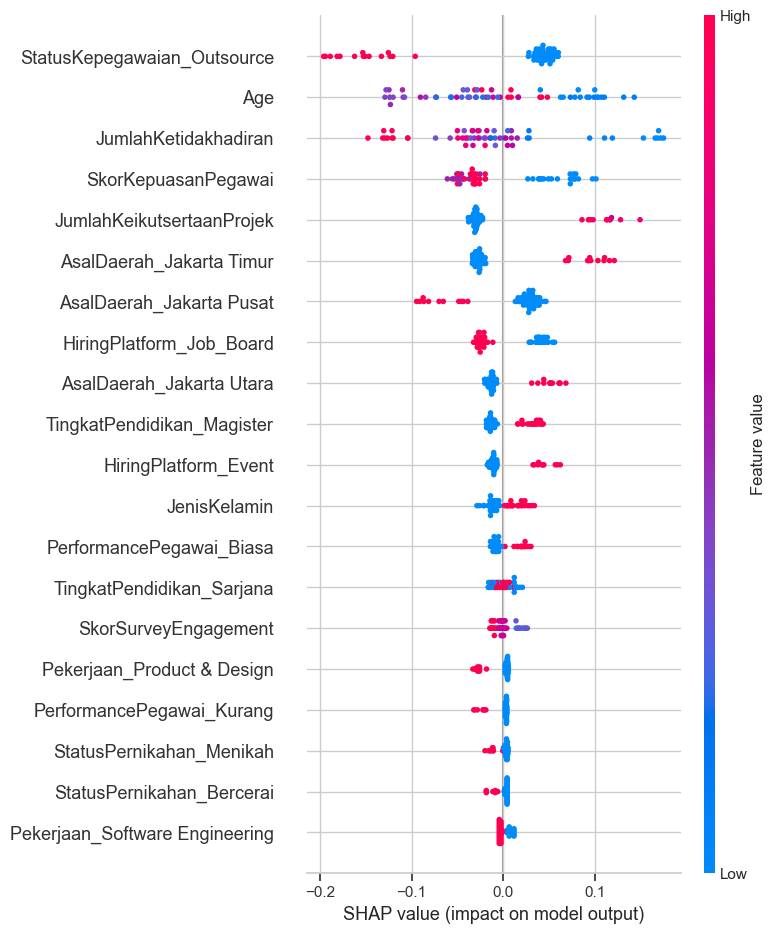

<Figure size 640x480 with 0 Axes>

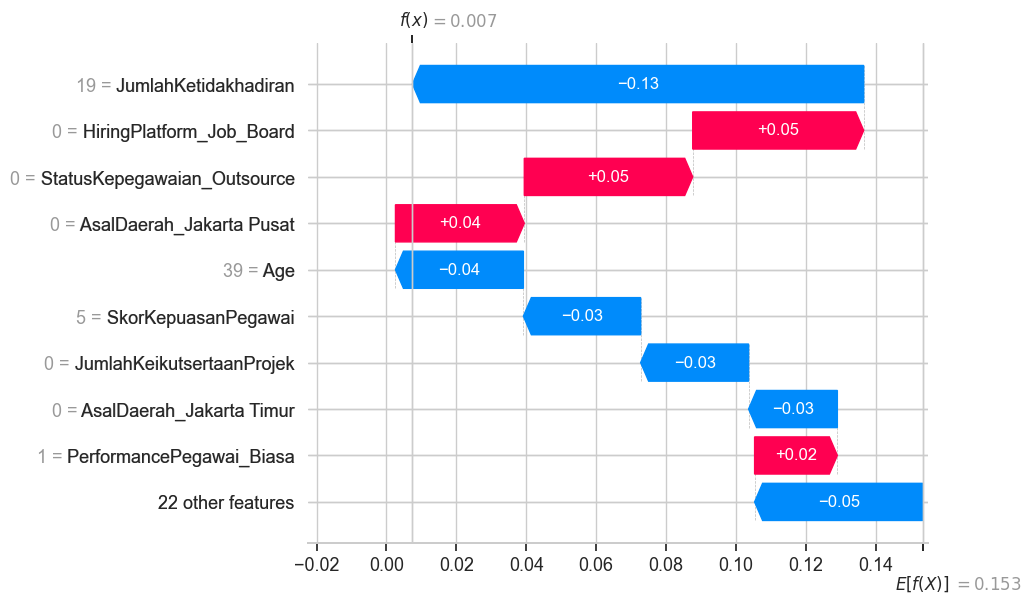

<Figure size 640x480 with 0 Axes>

c:\Users\arya wardhana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 7 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


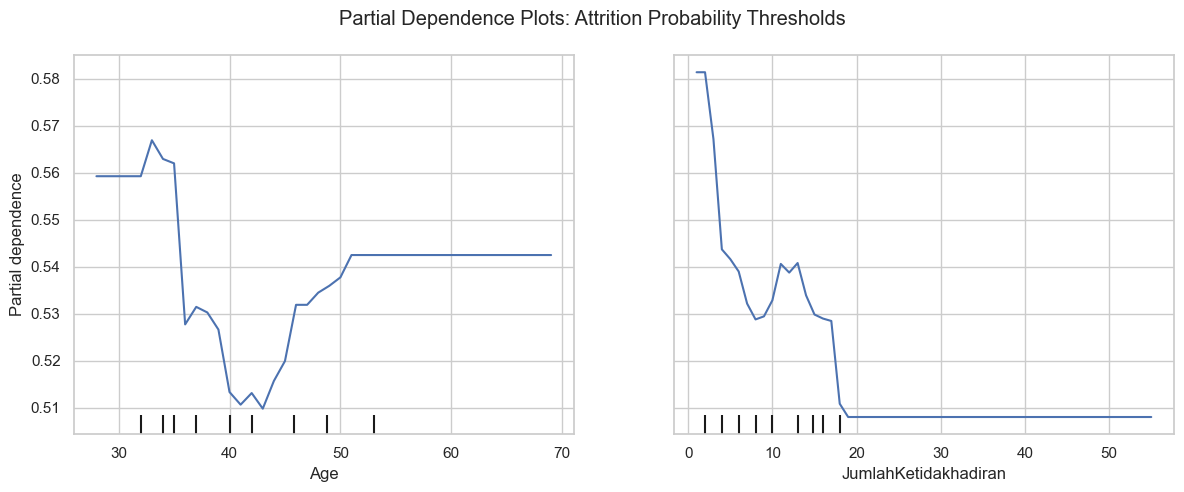

In [145]:
# ---------------------------------------------------------
# 1. SHAP VALUES (Global & Local Interpretability)
# ---------------------------------------------------------

xgb_tuned=best_xgb

# Initialize SHAP TreeExplainer for tuned XGBoost
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer(X_test)

# A. Summary Plot (Feature Importance + Direction of Effect)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")
plt.tight_layout()
plt.show()

# B. SHAP Waterfall Plot for a single employee (Local Explanation)
# Shows why employee #0 was predicted to resign or stay
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[0])
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. PARTIAL DEPENDENCE PLOTS (PDP) - Finding Thresholds
# ---------------------------------------------------------
# Inspect non-linear relationships for top features (e.g., Age & Absence Count)
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    xgb_tuned,
    X_train,
    features=['Age', 'JumlahKetidakhadiran'], 
    ax=ax
)
plt.suptitle('Partial Dependence Plots: Attrition Probability Thresholds')
plt.tight_layout()
plt.show()

# COBA_COBA/TEST_dRIVE

In [123]:
# Save DataFrame to Excel
#df02.to_csv("NEWDATA.csv", index=False)

In [124]:
df01[['Pekerjaan', 'HiringPlatform']].sample(10)

,Pekerjaan,HiringPlatform
77,Software Engineering,Job_Board
70,Software Engineering,Job_Board
21,Other,Job_Board
32,Software Engineering,Job_Board
240,Software Engineering,Event
140,Software Engineering,Event
204,Software Engineering,Event
118,Software Engineering,Job_Board
113,Product & Design,Job_Board
283,Product & Design,Job_Board


C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_34596\2742107547.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df01.select_dtypes(
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_34596\2742107547.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_34596\2742107547.py:26: FutureWarning:

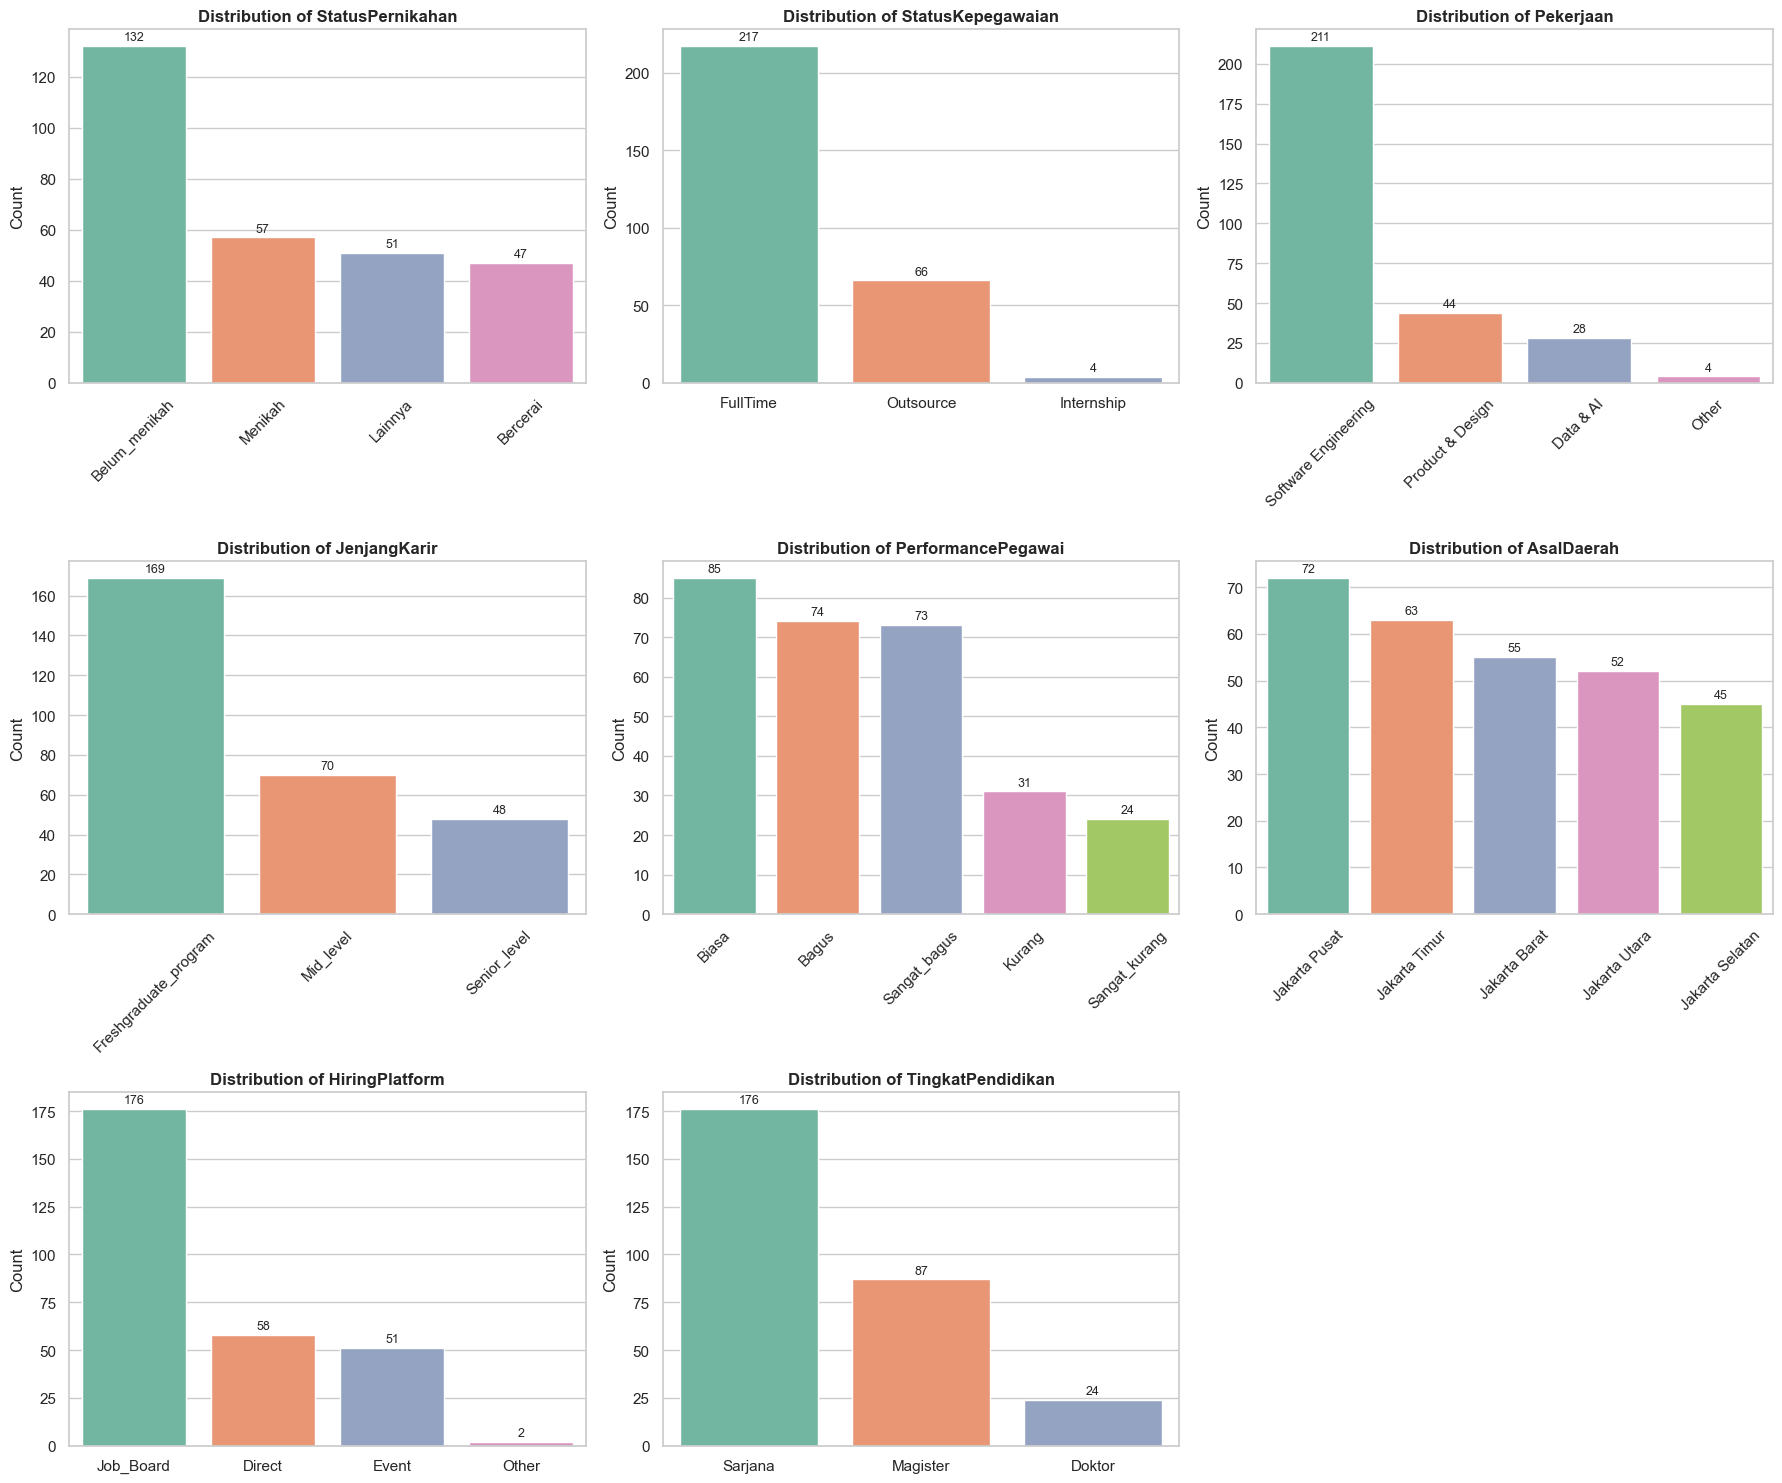

In [125]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all categorical (object, category, bool) columns
categorical_cols = df01.select_dtypes(
    include=["object", "category", "bool"]
).columns

# 2. Determine grid layout (e.g., 3 columns per row)
num_cols = len(categorical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy looping

# 4. Loop through columns and plot
for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # Create countplot (ordered by highest frequency)
    order = df01[col].value_counts().index
    sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    # Add count number labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points",
            )

    # Rotate labels if there are many unique values or long string names
    if df01[col].nunique() > 4 or df01[col].astype(str).str.len().max() > 10:
        ax.tick_params(axis="x", rotation=45)

# 5. Hide any extra unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

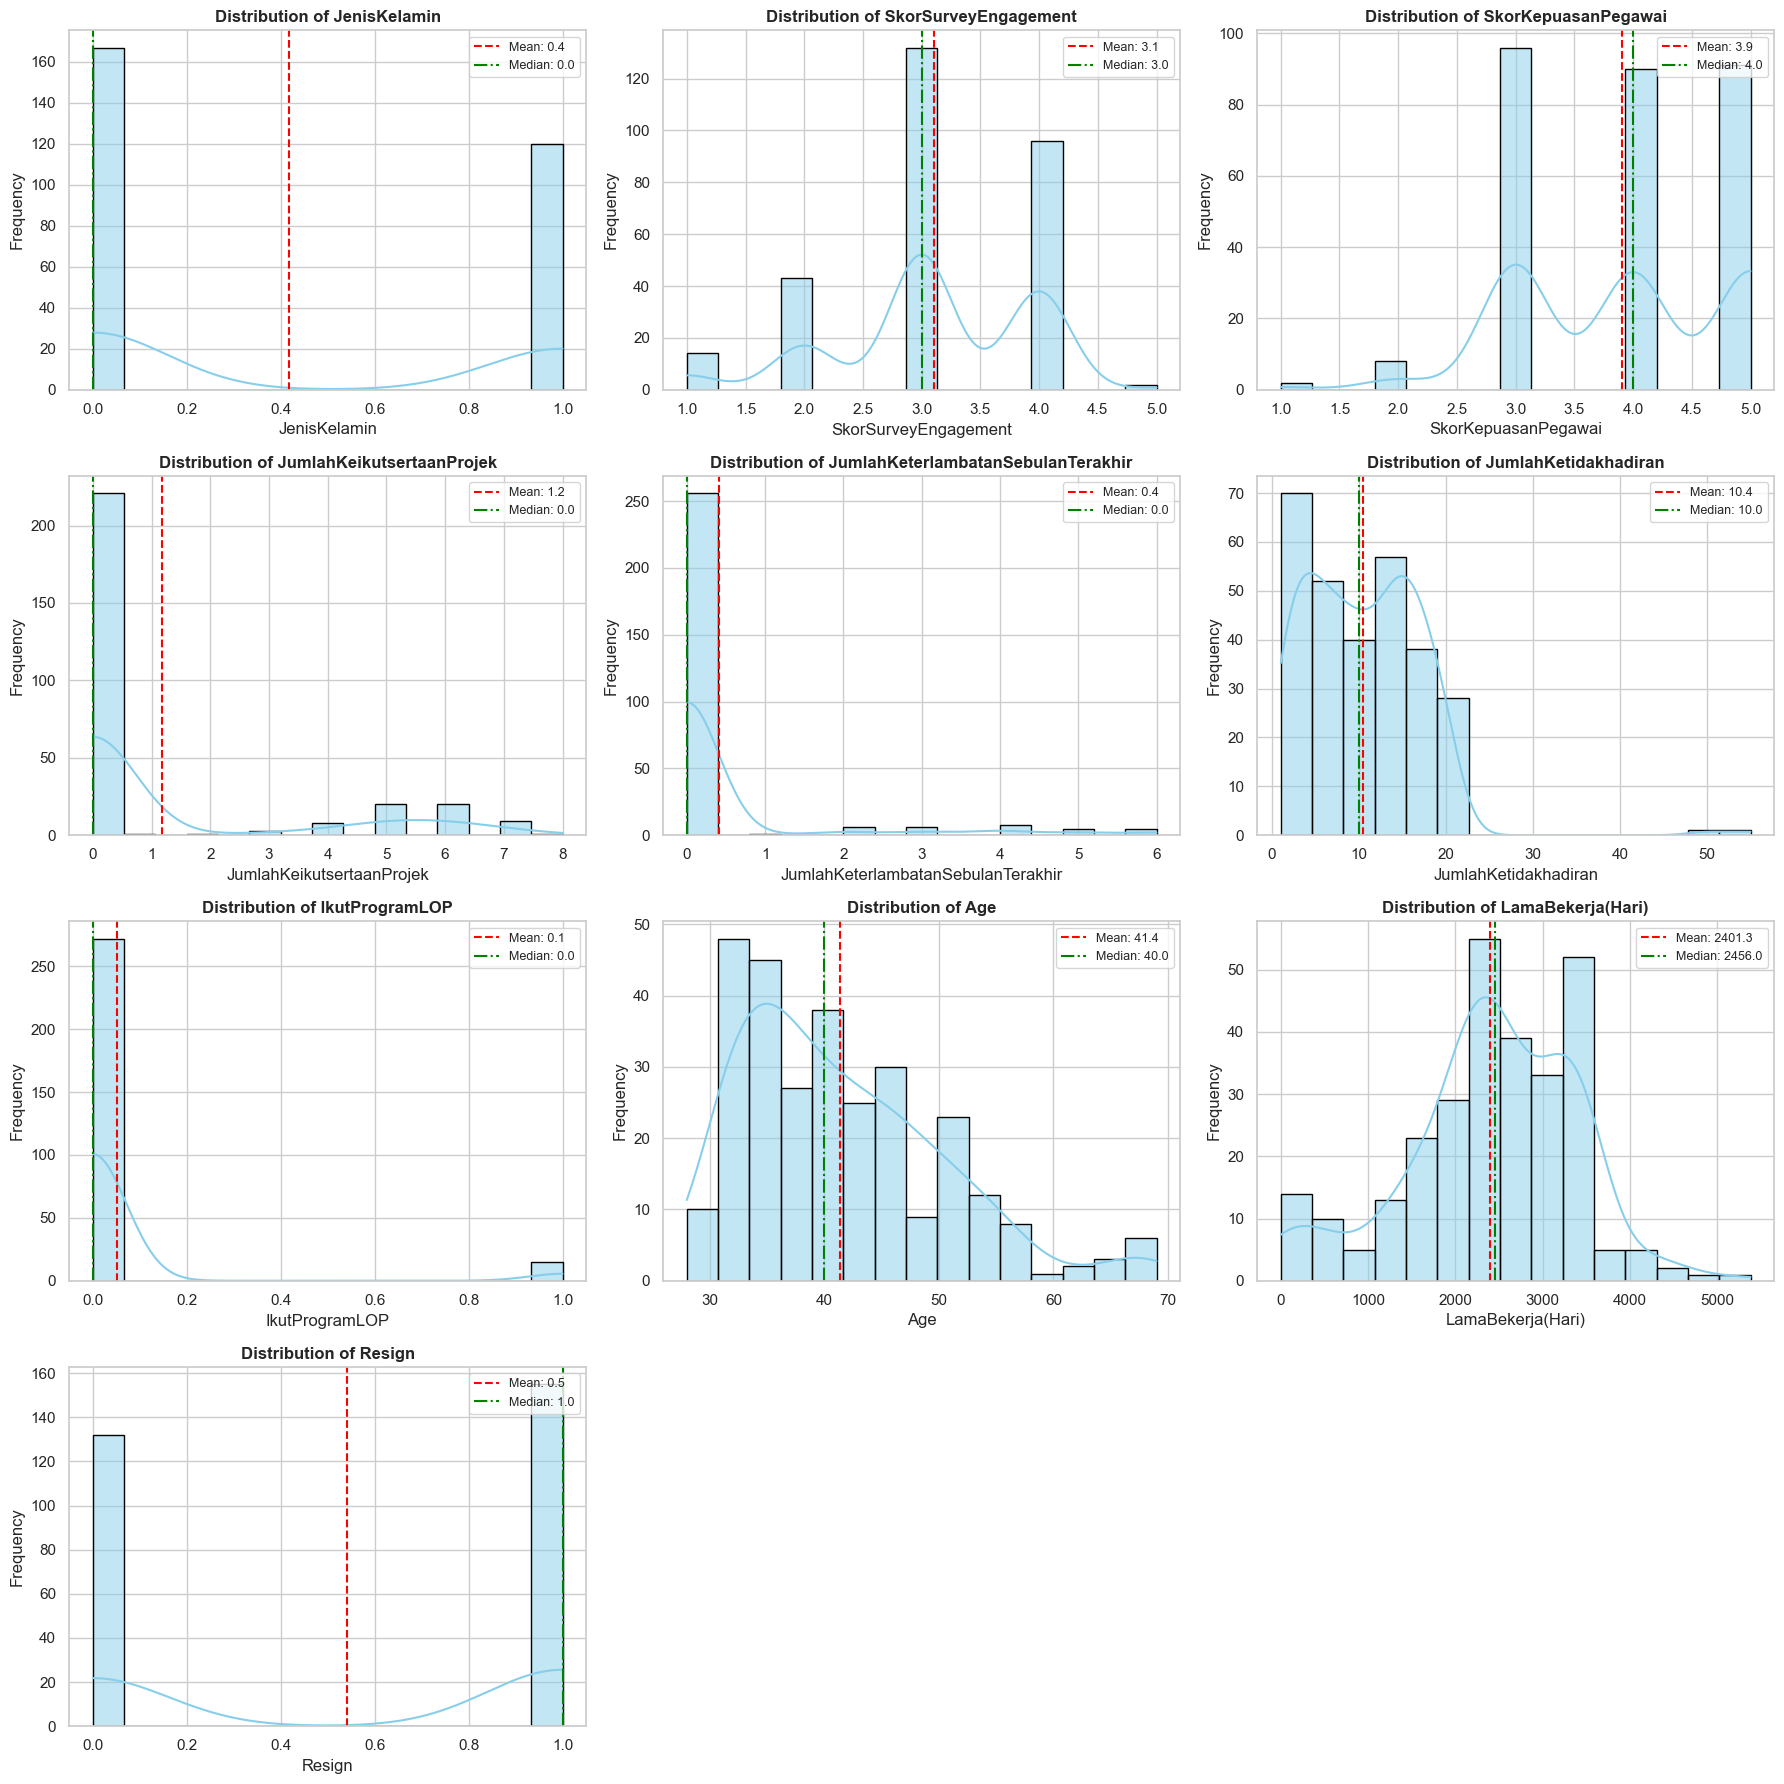

In [126]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all numerical (int, float) columns
numerical_cols = df01.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns

# 2. Determine grid layout (3 columns per row)
num_cols = len(numerical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 4.5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array into 1D for easy looping

# 4. Loop through numerical columns and plot histograms
for i, col in enumerate(numerical_cols):
    ax = axes[i]

    # Create histogram with KDE overlay
    sns.histplot(
        data=df01,
        x=col,
        kde=True,
        color="skyblue",
        edgecolor="black",
        bins=15,
        ax=ax,
    )

    # Calculate mean and median for visual reference
    mean_val = df01[col].mean()
    median_val = df01[col].median()

    # Add vertical dashed lines for mean (red) and median (green)
    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean: {mean_val:.1f}",
    )
    ax.axvline(
        median_val,
        color="green",
        linestyle="-.",
        linewidth=1.5,
        label=f"Median: {median_val:.1f}",
    )

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9, loc="upper right")

# 5. Hide any unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

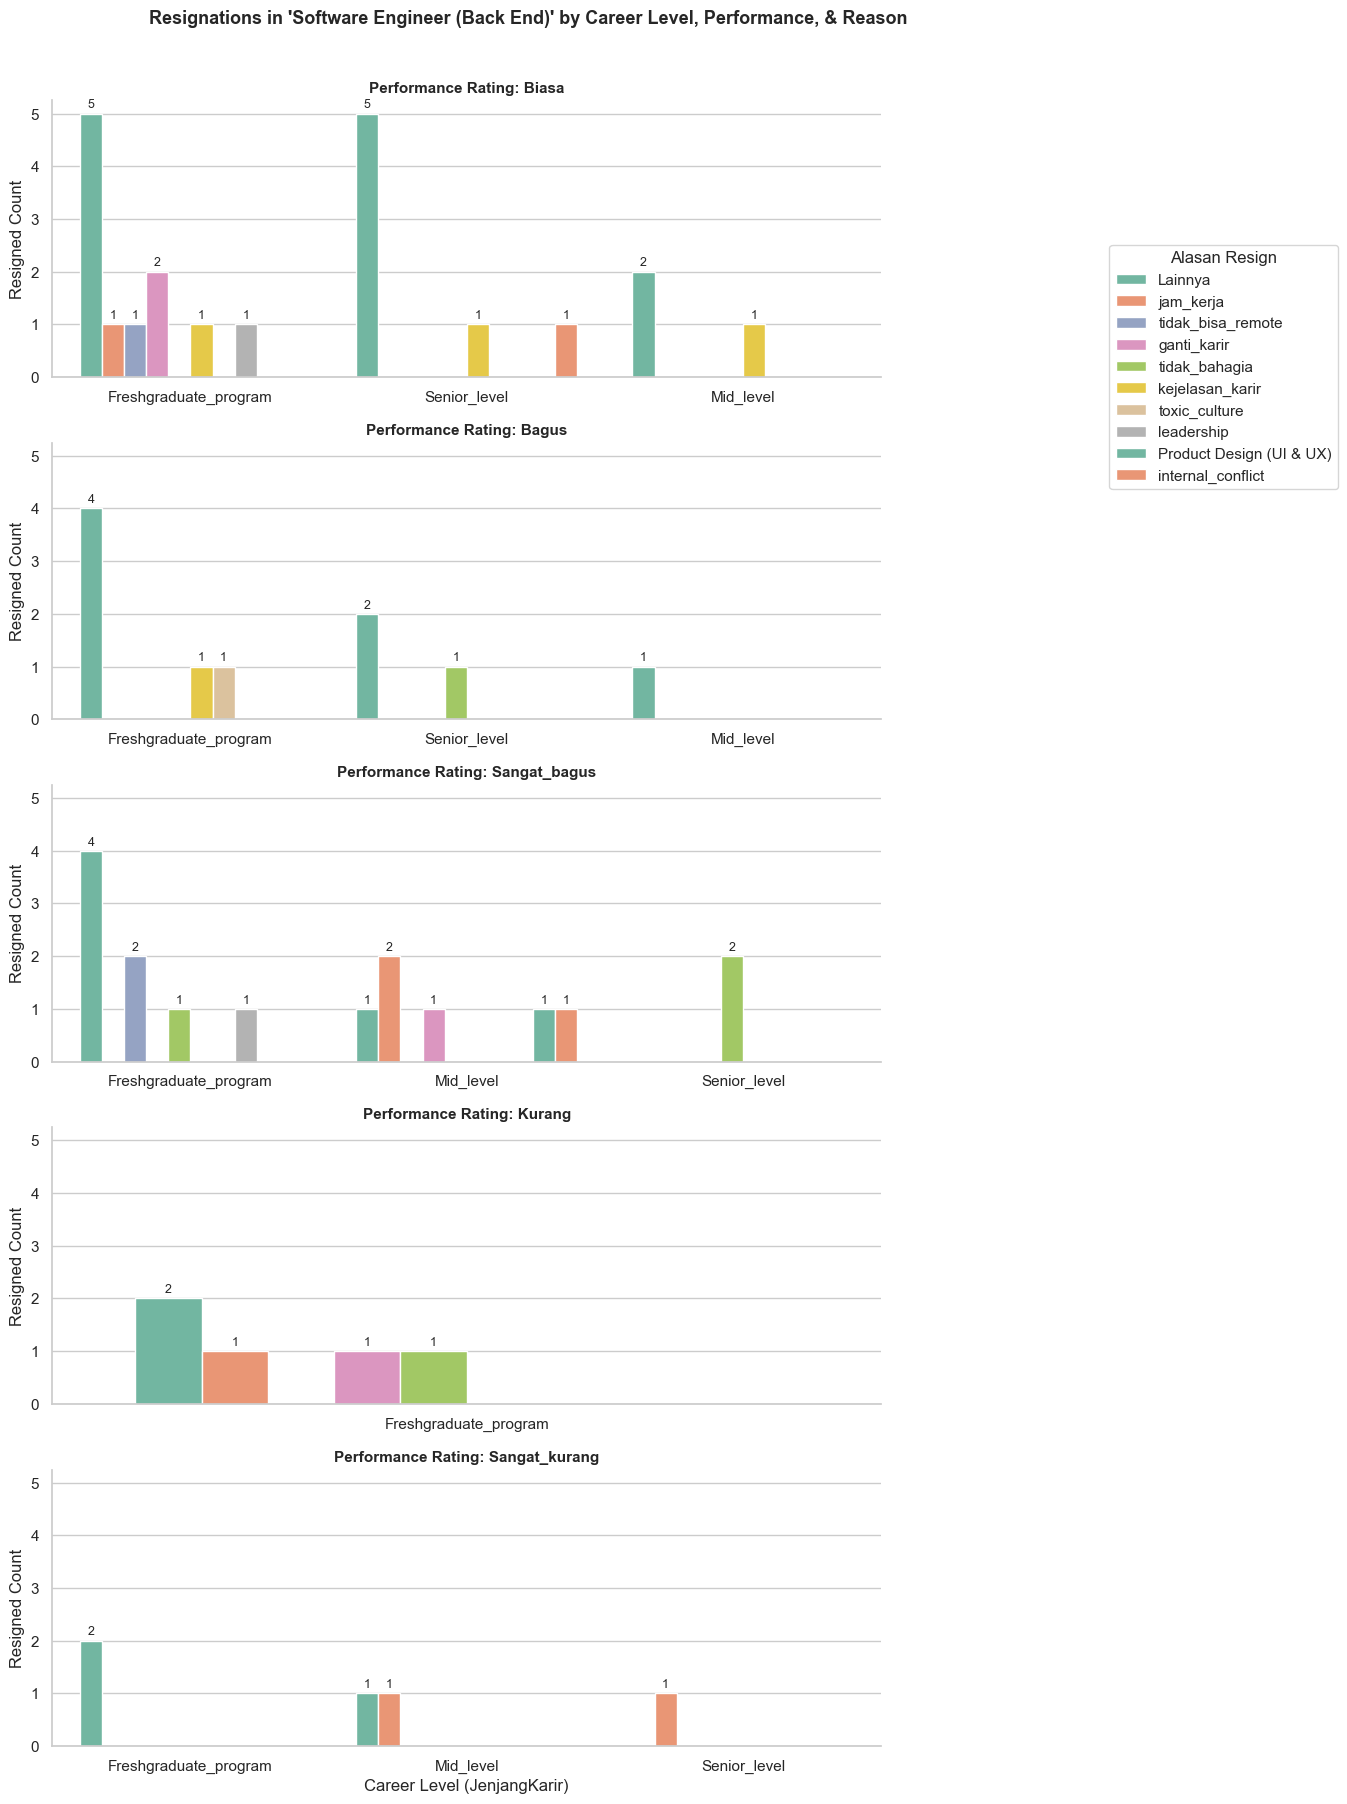

In [127]:
sns.set_theme(style="whitegrid")

# Create vertical facets
chart = sns.catplot(
    data=agg_target,
    x="JenjangKarir",
    y="ResignedCount",
    hue="AlasanResign",
    col="PerformancePegawai",
    col_wrap=1,  # Stack vertically
    kind="bar",
    palette="Set2",
    height=3.5,
    aspect=2.5,
    sharex=False,  # Keep career levels visible on all subplots
)

# Set titles and axis labels
chart.fig.suptitle(
    f"Resignations in '{target_division}' by Career Level, Performance, & Reason",
    y=1.03,
    fontsize=13,
    fontweight="bold",
)
chart.set_axis_labels("Career Level (JenjangKarir)", "Resigned Count")
chart.set_titles("Performance Rating: {col_name}", size=11, weight="bold")

# Move legend outside the plot area to the right
sns.move_legend(
    chart,
    loc="upper left",
    bbox_to_anchor=(1.02, 0.9),  # Places legend cleanly to the right
    title="Alasan Resign",
    frameon=True,
)

# Iterate through subplots to format ticks and bar labels
for ax in chart.axes.flat:
    ax.tick_params(labelbottom=True)  # Keep JenjangKarir visible

    # Add count numbers on top of bars
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points",
            )

# Adjust layout to make room for the right legend
plt.subplots_adjust(right=0.82)
plt.show()

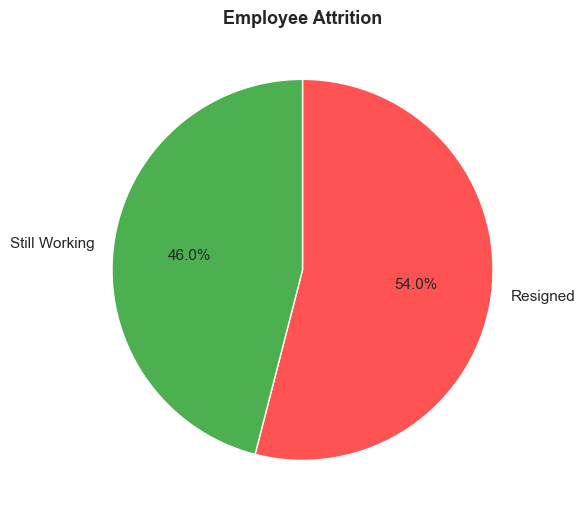

In [128]:
resign_counts = df02["Resign"].value_counts().sort_values(ascending=False)

label_map = {0: "Still Working", 1: "Resigned"}
labels = [label_map[x] for x in resign_counts.index]

color_map = {0: "#4CAF50", 1: "#FF5252"}
colors = [color_map[x] for x in resign_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    resign_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    textprops={'fontsize': 11}
)

plt.title("Employee Attrition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Hyperparatuning

In [129]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    precision_score, 
    recall_score, 
    accuracy_score, 
    roc_auc_score
)

# ---------------------------------------------------------
# 1. HYPERPARAMETER TUNING FOR RANDOM FOREST
# ---------------------------------------------------------

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize model and RandomizedSearchCV
rf_base = RandomForestClassifier(random_state=42)
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,            # Tries 20 combinations
    cv=5,                 # 5-fold cross-validation
    scoring='f1',         # Optimize for F1 score
    random_state=42,
    n_jobs=-1
)

# Fit tuning on training data
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best Parameters:", rf_search.best_params_)

# ---------------------------------------------------------
# 2. THRESHOLD TUNING (TO BOOST RECALL)
# ---------------------------------------------------------

# Get predicted probabilities for class 1 (Resigned)
y_probs = best_rf.predict_proba(X_test)[:, 1]

# Test different decision thresholds from 0.30 to 0.50
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]
threshold_results = []

for thresh in thresholds:
    # Predict positive if probability >= threshold
    y_pred_thresh = (y_probs >= thresh).astype(int)
    
    threshold_results.append({
        "Threshold": thresh,
        "Accuracy": round(accuracy_score(y_test, y_pred_thresh), 2),
        "Precision": round(precision_score(y_test, y_pred_thresh), 2),
        "Recall": round(recall_score(y_test, y_pred_thresh), 2),
        "F1 Score": round(f1_score(y_test, y_pred_thresh), 2),
        "ROC AUC": round(roc_auc_score(y_test, y_probs), 2)
    })

# Display comparative table across thresholds
thresh_df = pd.DataFrame(threshold_results)
print("\n--- Performance Across Decision Thresholds ---")
print(thresh_df.to_string(index=False))

Best Parameters: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}

--- Performance Across Decision Thresholds ---
 Threshold  Accuracy  Precision  Recall  F1 Score  ROC AUC
      0.50      0.59       0.59    0.71      0.65     0.62
      0.45      0.59       0.57    0.94      0.71     0.62
      0.40      0.57       0.56    0.97      0.71     0.62
      0.35      0.53       0.53    1.00      0.70     0.62
      0.30      0.53       0.53    1.00      0.70     0.62


In [130]:
# 1. Use your original best model
RandomForest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
RandomForest.fit(X_train, y_train)

# 2. Get probabilities
prob_rf = RandomForest.predict_proba(X_test)[:, 1]

# 3. Test lower decision thresholds (e.g., 0.45 or 0.40) to boost Recall
custom_threshold = 0.45
pred_rf_boosted = (prob_rf >= custom_threshold).astype(int)

print(f"--- Results at Threshold = {custom_threshold} ---")
print(f"Accuracy : {accuracy_score(y_test, pred_rf_boosted):.2f}")
print(f"Precision: {precision_score(y_test, pred_rf_boosted):.2f}")
print(f"Recall   : {recall_score(y_test, pred_rf_boosted):.2f}")
print(f"F1 Score : {f1_score(y_test, pred_rf_boosted):.2f}")

--- Results at Threshold = 0.45 ---
Accuracy : 0.64
Precision: 0.61
Recall   : 0.87
F1 Score : 0.72
